# scploid for aneuploid screen

data was pre-analysed using scploid (scploid.R)

In [1]:
.libPaths()

[1] "/software/cellgen/team292/rs40/envs/R_scploid/lib/R/library"

In [2]:
R.home()

[1] "/software/cellgen/team292/rs40/envs/R_scploid/lib/R"

In [3]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyverse)
  library(Matrix)
  library(Hmisc)
  library(reshape2)
  library(viridis)
  library(RColorBrewer)
  library(ggalluvial)
  library(gplots)
  library(grid)
library(scales)
library(rstatix)
library(ggpubr)
library(gridExtra)    
})

Warning message:
“package ‘Matrix’ was built under R version 4.4.3”
Warning message:
“package ‘Hmisc’ was built under R version 4.4.3”


In [4]:
options(tibble.width = Inf)
options(repr.matrix.max.cols = Inf)

## plot parameters

In [5]:
# define const for visualization
FONT.SIZE <- 7
LABEL.FONT.SIZE <- 7
w <- 2 
h <- 2.5
LINE.W <- 0.5/2.141959

# Set geom defaults globally
update_geom_defaults("line",      list(linewidth = LINE.W))
update_geom_defaults("errorbar",  list(linewidth = LINE.W))
#update_geom_defaults("point",     list(size = LINE.W, stroke = LINE.W))

settheme <- theme_minimal() + 
  theme(
    text = element_text(family = "sans"), 
    panel.background = element_blank(),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(),
    plot.background = element_blank(),
    axis.ticks = element_line(colour = "black", linewidth = LINE.W),
    axis.ticks.length = unit(0.1, "cm"), 
    axis.line = element_line(linewidth = LINE.W, colour = "black"),
    axis.title = element_text(size = FONT.SIZE),
    axis.text = element_text(colour = "black", size = FONT.SIZE),
    strip.text = element_text(size = FONT.SIZE), 
    strip.text.y.left = element_text(angle = 0, hjust = 1, size = FONT.SIZE),
    legend.position = "right",
    legend.title = element_text(size = FONT.SIZE), 
    legend.text = element_text(size = FONT.SIZE),
    legend.key.size = unit(0.3, "cm"),
    axis.text.x = element_text(colour = "black", angle = 0, size = LABEL.FONT.SIZE),
    title = element_text(size = FONT.SIZE) 
  )


In [6]:
custom_palette <- c(
  "#555e7b", "#b7d968", "#b576ad", "#e04644", "#fde47f", "#7ccce5", 
  "#C6E5D9", "#F0A830", "#e04644", "#C0D860", "#F2F26F", "#A8E6CE", 
  "#CCC68D", "#EB6841", "#E1F5C4", "#D9CEB2", "#C5CEAE", "#E84A5F", 
  "#A0C55F", "#DCE9BE", "#FFAAA6", "#F07818", "#E08E79", "#A0C55F", 
  "#948C75", "#C0D860", "#005F6B", "#45484B", "#0B2E59", "#FFF7BD", 
  "#CFBE27", "#F1D4AF", "#C02942", "#5E412F", "#355C7D", "#F27435", 
  "#AAB3AB", "#4ECDC4", "#8C2318", "#FF9E9D", "#E6AC27", "#C7F464", 
  "#4ECDC4", "#ED303C", "#F4FAD2", "#F07818", "#031634", "#838689", 
  "#73626E", "#F9D423", "#C06C84", "#F04155", "#F5634A", "#DFBA69", 
  "#A0C55F"
)

color_ploidy = c("diploid"= "white","normal"= "white", "monosomy"="#109E9D","trisomy"="#F26B3B","complex"= "#886DB0")
color_ploidy_2 = c("diploid"= adjustcolor("grey77", alpha = 0.5) ,"normal"= "white", "monosomy"="#109E9D","trisomy"="#F26B3B","complex"= "#886DB0")
color_ploidy_chr = c("normal"= "white","monosomy"="#109E9D","trisomy"="#F26B3B")

color_condition = c("Control" = "#7BBA56", 
               "Reversine" = "#87549B", 
               "Mosaic" = "#E8973E")

color_celltype = c("EPI"    = "#EA9542", 
                   "TE"       = "#3E7CB5", 
                   "unspecified"       = "#7CBA59")

color_sample = c(
  # Control group colors
  "T1_control" = "#B5C649",
  "T2_control" = "#66BC52",
  "T3_control" = "#009791",
  # Reversine group colors
  "T1_rev" = "#B686BD",
  "T2_rev" = "#A263B2",
  "T3_naive_rev" = "#754383",
  "T3_rev" = "#4A314F",
  # Mix group colors
  "T2_mix" = "#FDCF5F",
  "T3_mix_good" = "#F29923",
  "T3_mix_bad" = "#945200"
)



levels_vec <- as.character(1:22)
col_monosomy <- viridis_pal(option = "mako")(22)
names(col_monosomy) <- rev(levels_vec)

levels_vec <- as.character(1:22)
col_trisomy <- viridis_pal(option = "rocket")(22)
names(col_trisomy) <- rev(levels_vec)

#c("normal"= "#E0E0E0","monosomy"="#109E9D","trisomy"="#F26B3B")

## input files and output directories

In [7]:
ploidydf = read.csv("/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/ploidydf.csv")
cell_karyotype = read.csv("/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/cell_karyotype_scploid.csv")
scanpy_meta = read.csv( "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/3_scanpy_integration/meta_integrated_sub_fine.csv")
BC_df = read.csv('/nfs/team292/rs40/projects/Aneuploid_screen/processed_data/barcode/BC_df.csv')

In [8]:
outdir = '/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid'

## Reformat

In [9]:
head(ploidydf, 3)

,chr,cell,z,score,p,p.adj,monosomy,ploidy
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
1,1,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.007713042,0.9976855,0.9938460,1.0000000,TRUE,normal
2,10,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.722146042,0.9367999,0.4702108,0.9910863,TRUE,normal
3,11,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1.896537105,1.1236714,0.0578994,0.3990391,FALSE,normal


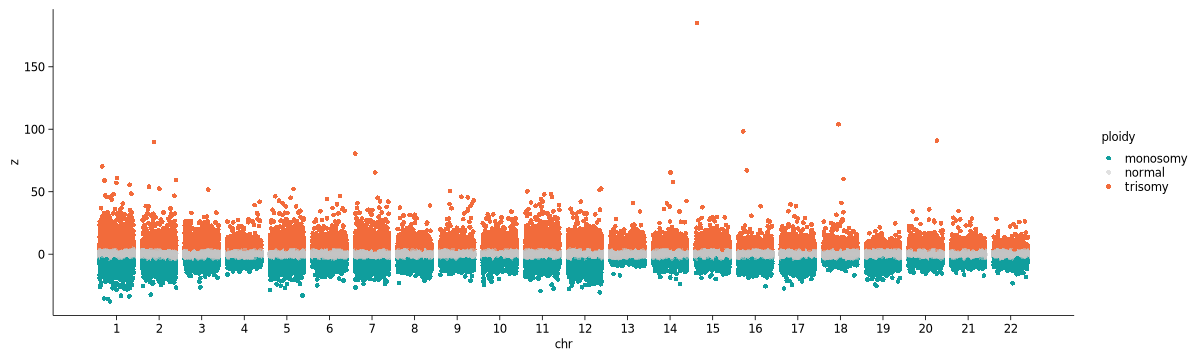

In [10]:
#plot
title = "z_score_jitter"

w <- 10
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

z_score_jitter = ggplot(ploidydf,aes(chr,z,col=ploidy))+
                settheme+
                geom_jitter(size=1,shape=16)+
                scale_x_continuous(breaks = seq(1,22, by = 1)) +
                scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = z_score_jitter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

z_score_jitter

Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_bar()`).”


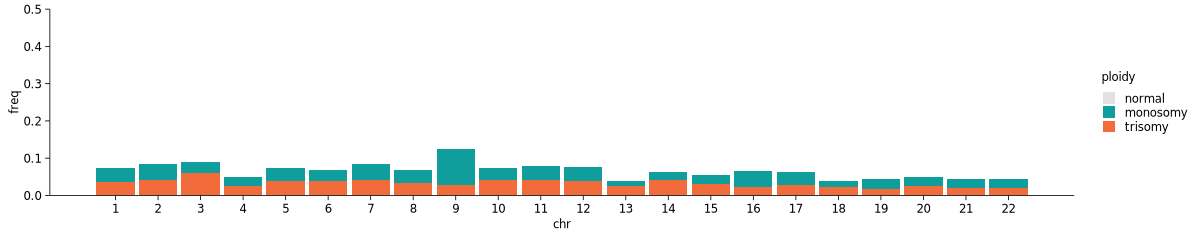

In [11]:
#plot
title = "freq_perchr_bar"

w <- 10
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
ploidydf$ploidy <- factor(ploidydf$ploidy, levels = order)

gg_bar = ggplot(ploidydf, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill')+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.5))+
    scale_x_continuous(breaks = seq(1,22, by = 1)) +
  labs(y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

### cell_chr

In [12]:
cell_chr_df <- ploidydf  %>%
  select(cell, chr, ploidy)%>%
  pivot_wider(names_from = chr, values_from = ploidy) %>%
  column_to_rownames("cell")

In [13]:
head(cell_chr_df)

,1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,3,4,5,6,7,8,9
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACGGGAGGACAGAA-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACGGGGTTACGACT-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAAGATGCACAGATTC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAAGATGCAGGAATCG-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal


In [14]:
write.csv(cell_chr_df,sprintf("%s/cell_chr_scploid.csv",outdir), row.names = TRUE)

In [15]:
sprintf("%s/cell_chr_df_matrix.csv",outdir)

[1] "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/cell_chr_df_matrix.csv"

### cell_karyotype

In [16]:
#add karyotype info
karyotype_summary <- ploidydf %>%
  # Ensure chromosomes are sorted numerically for a clean final string
  arrange(cell, as.numeric(chr)) %>% 
  
  # Create a label for each row based on ploidy
  mutate(event = case_when(
    ploidy == "trisomy" ~ paste0(chr, "+"),   # Trisomy / Gain
    ploidy == "monosomy" ~ paste0(chr, "-"),   # Monosomy / Loss
    TRUE ~ NA_character_             # Normal (ploidy 2), mark as NA to ignore later
  )) %>%
  
  # Filter out the 'normal' rows so they don't clutter the string
  filter(!is.na(event)) %>%
  
  # Group by cell and collapse the events into a single string
  group_by(cell) %>%
  summarise(karyotype = paste(event, collapse = ", ")) %>%
  
  # Join back to original list of cells to ensure 'normal' cells appear
  right_join(distinct(ploidydf, cell), by = "cell") %>%
  
  # Fill in the NAs for cells that had no events
  mutate(karyotype = ifelse(is.na(karyotype), "diploid", karyotype))

#summarise the karyotype info
final_summary <- karyotype_summary %>%
  mutate(ploidy = case_when(
    # 1. Check for Normal
    karyotype == "diploid" ~ "diploid",
    
    # 2. Check for single Trisomy: Exactly one '+' AND zero '-'
    str_count(karyotype, "\\+") == 1 & str_count(karyotype, "-") == 0 ~ "trisomy",
    
    # 3. Check for single Monosomy: Exactly one '-' AND zero '+'
    str_count(karyotype, "-") == 1 & str_count(karyotype, "\\+") == 0 ~ "monosomy",
    
    # 4. Everything else (multiple events, mixed gains/losses) -> Complex
    TRUE ~ "complex"
  ))

#add number of chromosomes
cell_karyotype <- final_summary %>%
  mutate(
    # Count occurrences of "+" (escape with \\ because + is a special regex character)
    num_gain_chr = str_count(karyotype, "\\+"),
    
    # Count occurrences of "-"
    num_loss_chr = str_count(karyotype, "-"),
    
    # Apply the math: Start at 44, add gains, subtract losses
    num_chr = 44 + num_gain_chr - num_loss_chr,
    num_abnormal_chr = num_gain_chr + num_loss_chr
  )

# View result
head(cell_karyotype, 10)

cell,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>
AAACCTGAGACGCTTT-1_Embryo-Imp15265942,13+,trisomy,1,0,45,1
AAACCTGAGATCGGGT-1_Embryo-Imp15265944,16-,monosomy,0,1,43,1
AAACCTGAGCCGATTT-1_Embryo-Imp15265941,"3+, 4+, 15-, 16-, 17-",complex,2,3,43,5
AAACCTGAGCGATCCC-1_Embryo-Imp15265941,15-,monosomy,0,1,43,1
AAACCTGAGCGTTGCC-1_Embryo-Imp15265940,"1+, 11+, 12+, 14+, 17+, 20+",complex,6,0,50,6
AAACCTGAGCTATGCT-1_Embryo-Imp15265941,"9-, 16-, 21+",complex,1,2,43,3
AAACCTGAGGCTCATT-1_Embryo-Imp15265946,"1+, 3+, 15+",complex,3,0,47,3
AAACCTGAGTAGTGCG-1_Embryo-Imp15265940,"6+, 9-, 12+",complex,2,1,45,3
AAACCTGAGTATTGGA-1_Embryo-Imp15265947,"2-, 8+, 9-, 11+, 16+, 17-, 19-, 20+",complex,4,4,44,8


In [17]:
write.csv(cell_karyotype,sprintf("%s/cell_karyotype_scploid.csv",outdir), row.names = TRUE)

## Plots per sample

### A) Tile cell x chr

In [18]:
# 1. Prepare the Heatmap Data
heatmap_data <- cell_chr_df %>%
  # Move row names (cells) to a real column
  rownames_to_column(var = "cell.ID_") %>%
  
  # Reshape wide -> long: Create 'chr' and 'state' columns
  pivot_longer(
    cols = -"cell.ID_", 
    names_to = "chr", 
    values_to = "state"
  ) %>%
  
  # Join with your metadata to get 'sample' info
  left_join(scanpy_meta, by = "cell.ID_") %>%
  mutate(chr = factor(chr, levels = sort(unique(as.numeric(chr)))))

head(heatmap_data, 3)

cell.ID_,chr,state,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
<chr>,<fct>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,10,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,11,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified


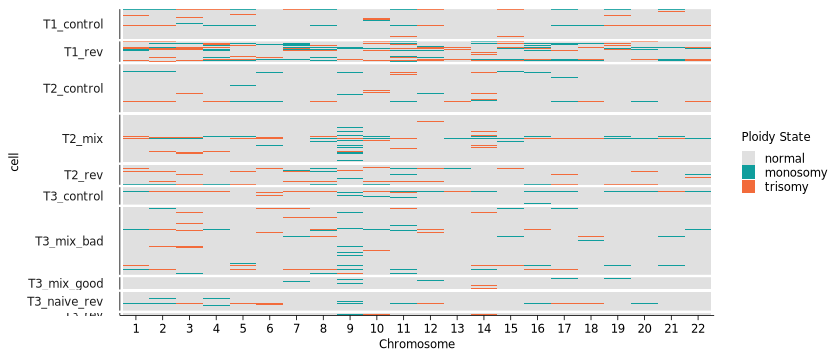

In [19]:
#plot
title = "A_heatmap_ploidy_sample"

w <- 7
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

gggeom = ggplot(heatmap_data, aes(x = chr, y = cell.ID_, fill = state)) +
  geom_tile() + # Add thin white borders
  #rasterise(geom_tile(), dpi = 300) +
  # Define your biology-specific colors
  scale_fill_manual(values = c("normal"= "#E0E0E0","monosomy"="#109E9D","trisomy"="#F26B3B")) +
  
  # Group cells visually by faceting (splitting) by Sample
  facet_grid(sample ~ ., scales = "free_y", space = "free_y", switch = "y") +
  # Clean up the look
  theme_minimal() +
  labs(x = "Chromosome", y = "cell", fill = "Ploidy State") +
  settheme+
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    panel.grid = element_blank(),
    strip.placement = "outside",
    strip.text.y.left = element_text(angle = 0, hjust = 1),
      panel.spacing = unit(0.1, "lines")
  )

#ggsave(plot = gggeom, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggsave(plot = gggeom, filename = sprintf("%s/%s.png", outdir, title), 
       w = w, h = h, dpi = 300)
gggeom

### B) % anuploid per chr

In [20]:
colnames(scanpy_meta)

[1] "X"                        "dataset"                 
 [3] "cell.ID_"                 "scrublet_score"          
 [5] "scrublet_prediction"      "scrublet_cluster_score"  
 [7] "scrublet_zscore"          "scrublet_bh_pval"        
 [9] "scrublet_bonf_pval"       "n_genes_by_counts"       
[11] "total_counts"             "total_counts_mt"         
[13] "pct_counts_mt"            "total_counts_ribo"       
[15] "pct_counts_ribo"          "n_genes_group"           
[17] "S_score"                  "G2M_score"               
[19] "phase"                    "leiden"                  
[21] "mef_score"                "persample_celltype"      
[23] "sample_celltype"          "sample"                  
[25] "timepoint"                "Condition"               
[27] "State"                    "n_genes"                 
[29] "stress_score_vandenBrink" "leiden_theta0"           
[31] "leiden_theta1"            "leiden_theta2"           
[33] "leiden_theta3"            "integrated_celltype"     
[35] "leiden_lowres"            "celltype_fine"           
[37] "celltype_coarse"

In [21]:
merged_ploidydf <- inner_join(ploidydf, scanpy_meta, by = c("cell" = "cell.ID_"))

In [22]:
head(merged_ploidydf)

,chr,cell,z,score,p,p.adj,monosomy,ploidy,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,1,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.007713042,0.9976855,0.9938460,1.0000000,TRUE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
2,10,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.722146042,0.9367999,0.4702108,0.9910863,TRUE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
3,11,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1.896537105,1.1236714,0.0578994,0.3990391,FALSE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
4,12,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1.087522923,1.0652606,0.2768152,0.8782793,FALSE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
5,13,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.897502111,0.8741527,0.3694588,0.9482101,TRUE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
6,14,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,0.206836155,1.0023145,0.8361393,1.0000000,FALSE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified


Warning message:
“Removed 220 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 220 rows containing missing values or values outside the scale range
(`geom_bar()`).”


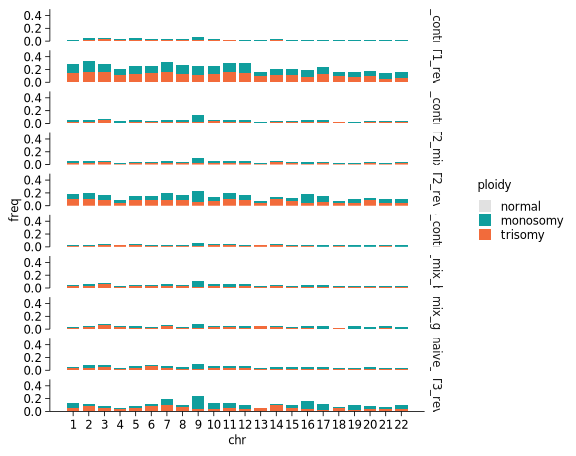

In [23]:
#plot
title = "B_freq_perchr_bar"

w <- 4.8
h <- 3.8
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
merged_ploidydf$ploidy <- factor(merged_ploidydf$ploidy, levels = order)

gg_bar = ggplot(merged_ploidydf, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill', width = 0.8)+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.5), breaks = seq(0, 0.5, by = 0.2))+
  scale_x_continuous(breaks = seq(1,22, by = 1))+
  labs(y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))+
  facet_grid(sample ~.)

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

### C) % aneuploid cell per condition

In [24]:
merged_cellkaryotype <- inner_join(cell_karyotype, scanpy_meta, by = c("cell" = "cell.ID_"))

In [25]:
colnames(merged_cellkaryotype)

[1] "cell"                     "karyotype"               
 [3] "ploidy"                   "num_gain_chr"            
 [5] "num_loss_chr"             "num_chr"                 
 [7] "num_abnormal_chr"         "X"                       
 [9] "dataset"                  "scrublet_score"          
[11] "scrublet_prediction"      "scrublet_cluster_score"  
[13] "scrublet_zscore"          "scrublet_bh_pval"        
[15] "scrublet_bonf_pval"       "n_genes_by_counts"       
[17] "total_counts"             "total_counts_mt"         
[19] "pct_counts_mt"            "total_counts_ribo"       
[21] "pct_counts_ribo"          "n_genes_group"           
[23] "S_score"                  "G2M_score"               
[25] "phase"                    "leiden"                  
[27] "mef_score"                "persample_celltype"      
[29] "sample_celltype"          "sample"                  
[31] "timepoint"                "Condition"               
[33] "State"                    "n_genes"                 
[35] "stress_score_vandenBrink" "leiden_theta0"           
[37] "leiden_theta1"            "leiden_theta2"           
[39] "leiden_theta3"            "integrated_celltype"     
[41] "leiden_lowres"            "celltype_fine"           
[43] "celltype_coarse"

In [26]:
nrow(merged_cellkaryotype)

[1] 38655

In [27]:
#percentage of cells per ploidy group
per_ploidy = 
merged_cellkaryotype %>%
  group_by(sample, ploidy) %>%
  summarise(count = n()) %>%
  mutate(per = count / sum(count)) %>%
  mutate(total =sum(count))

head(per_ploidy)

`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.


sample,ploidy,count,per,total
<chr>,<chr>,<int>,<dbl>,<int>
T1_control,complex,442,0.10908193,4052
T1_control,diploid,2742,0.67670286,4052
T1_control,monosomy,525,0.12956565,4052
T1_control,trisomy,343,0.08464956,4052
T1_rev,complex,1799,0.64549695,2787
T1_rev,diploid,554,0.19878005,2787


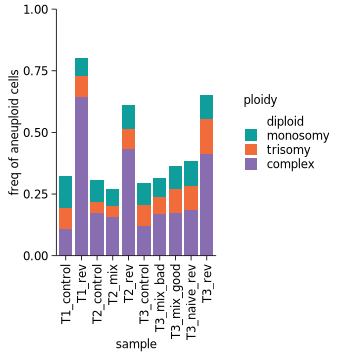

In [31]:
#plot
title = "C_per_aneu_cell_condition"
w <- 2.85
h <- 3
options(repr.plot.width=w, repr.plot.height=h)


order = c("diploid","monosomy","trisomy","complex" )
per_ploidy$ploidy <- factor(per_ploidy$ploidy, levels = order)

ggbar = ggplot(per_ploidy, aes(x=sample, y=per, fill = ploidy)) +
          geom_bar(stat="identity", width = 0.85)+
          settheme+
          scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
          labs(y= "freq of aneuploid cells")+
          scale_fill_manual(values=color_ploidy)+
          theme(axis.text.x = element_text(colour = "black", angle = 90, vjust=0.5, hjust = 1))
  
ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

### D) Histogram number of chromosome

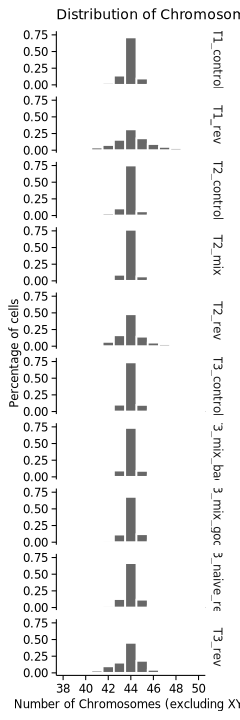

In [29]:
# plot
title = "D_hist_num_chr_percent"

w <- 2
h <- 6
options(repr.plot.width=w, repr.plot.height=h)

x_breaks <- seq(38, 50, by = 2) 
y_breaks <- seq(0, 1, by = 0.25)

gghist = ggplot(merged_cellkaryotype, aes(x = num_chr, y = after_stat(density))) +
  geom_histogram(binwidth = 1, fill = "#676767", color = "white") +
  scale_x_continuous(breaks = x_breaks) +
  scale_y_continuous(breaks = y_breaks) +
  coord_cartesian(xlim =  c(38, 50)) +
  facet_grid(sample ~ .)+
  theme_minimal() +
  labs(
    title = "Distribution of Chromosome Counts per Sample",
    x = "Number of Chromosomes (excluding XY)",
    y = "Percentage of cells"
  ) + settheme

  
ggsave(plot = gghist, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gghist

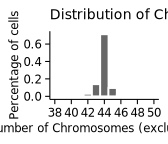

In [30]:
# plot
title = "D_hist_num_chr_percent_ctr"

w <- 1.4
h <- 1.2
options(repr.plot.width=w, repr.plot.height=h)

x_breaks <- seq(38, 50, by = 2) 
y_breaks <- seq(0, 1, by = 0.2)

gghist = ggplot(merged_cellkaryotype%>% subset(sample == "T1_control") , aes(x = num_chr, y = after_stat(density))) +
  geom_histogram(binwidth = 1, fill = "#676767", color = "white") +
  scale_x_continuous(breaks = x_breaks) +
  scale_y_continuous(breaks = y_breaks) +
  coord_cartesian(xlim =  c(38, 50)) +
  #facet_grid(sample ~ .)+
  theme_minimal() +
  labs(
    title = "Distribution of Chromosome Counts per Sample",
    x = "Number of Chromosomes (excluding XY)",
    y = "Percentage of cells"
  ) + settheme

  
ggsave(plot = gghist, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gghist

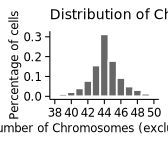

In [31]:
# plot
title = "D_hist_num_chr_percent_rev"

w <- 1.4
h <- 1.2
options(repr.plot.width=w, repr.plot.height=h)

x_breaks <- seq(38, 50, by = 2) 
y_breaks <- seq(0, 1, by = 0.1)

gghist = ggplot(merged_cellkaryotype%>% subset(sample == "T1_rev") , aes(x = num_chr, y = after_stat(density))) +
  geom_histogram(binwidth = 1, fill = "#676767", color = "white") +
  scale_x_continuous(breaks = x_breaks) +
  scale_y_continuous(breaks = y_breaks) +
  coord_cartesian(xlim =  c(38, 50)) +
  #facet_grid(sample ~ .)+
  theme_minimal() +
  labs(
    title = "Distribution of Chromosome Counts per Sample",
    x = "Number of Chromosomes (excluding XY)",
    y = "Percentage of cells"
  ) + settheme

  
ggsave(plot = gghist, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gghist

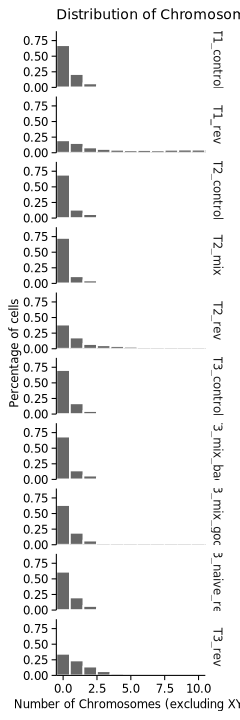

In [32]:
# plot
title = "D2_hist_num_abnormal_chr"
w <- 2
h <- 6
options(repr.plot.width=w, repr.plot.height=h)

# Define the breaks for the x-axis (e.g., from 10 to 30 by 2)
# You can adjust the '10' and '30' to match your actual data range
#x_breaks <- seq(10, 30, by = 2) 

gghist = ggplot(merged_cellkaryotype, aes(x = num_abnormal_chr, y = after_stat(density))) +
  geom_histogram(binwidth = 1, fill = "#676767", color = "white") +
  scale_y_continuous(expand = c(0, 0), limits = c(0, .9), breaks = seq(0, 1, by = 0.25) )+
  #scale_x_continuous(breaks = x_breaks) +
  coord_cartesian(xlim = c(0, 10))+
  facet_grid(sample ~ .)+
  theme_minimal() +
  labs(
    title = "Distribution of Chromosome Counts per Sample",
    x = "Number of Chromosomes (excluding XY)",
    y = "Percentage of cells"
  ) + settheme

  
ggsave(plot = gghist, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gghist

### E) Heatmap of karyotypes

In [33]:
# 1. Aggregate: Count cells per (Sample + Karyotype)
merged_cellkaryotype_counts <- merged_cellkaryotype %>%
  filter(ploidy != "diploid" & ploidy != "normal") %>%
  group_by(sample, karyotype, ploidy) %>%
  summarise(count = n(), .groups = "drop") %>%
  
  # This calculates: (Count of specific karyotype) / (Total aneuploid cells in sample)
  group_by(sample) %>%
  mutate(prop = count / sum(count)) %>%
  ungroup()

# 2. Get the LIST of top names (based on total abundance)
top_karyotypes <- merged_cellkaryotype_counts %>%
  group_by(karyotype) %>%
  summarise(total = sum(count)) %>%
  slice_max(total, n = 150) %>%
  pull(karyotype)

# 3. Filter using that list
heatmap_data_filtered <- merged_cellkaryotype_counts %>%
  filter(karyotype %in% top_karyotypes)

# 4. Define the Sorting Logic (Monosomy -> Trisomy -> Complex)
sorted_levels <- heatmap_data_filtered %>%
  distinct(karyotype, ploidy) %>%
  mutate(
    chr_num = as.numeric(str_extract(karyotype, "\\d+")),
    group_rank = case_when(
      ploidy == "monosomy" ~ 1,
      ploidy == "trisomy"  ~ 2,
      TRUE                 ~ 3 
    )
  ) %>%
  arrange(group_rank, chr_num) %>%
  pull(karyotype)

# 5. Apply this order
heatmap_data_filtered <- heatmap_data_filtered %>%
  mutate(karyotype = factor(karyotype, levels = sorted_levels))

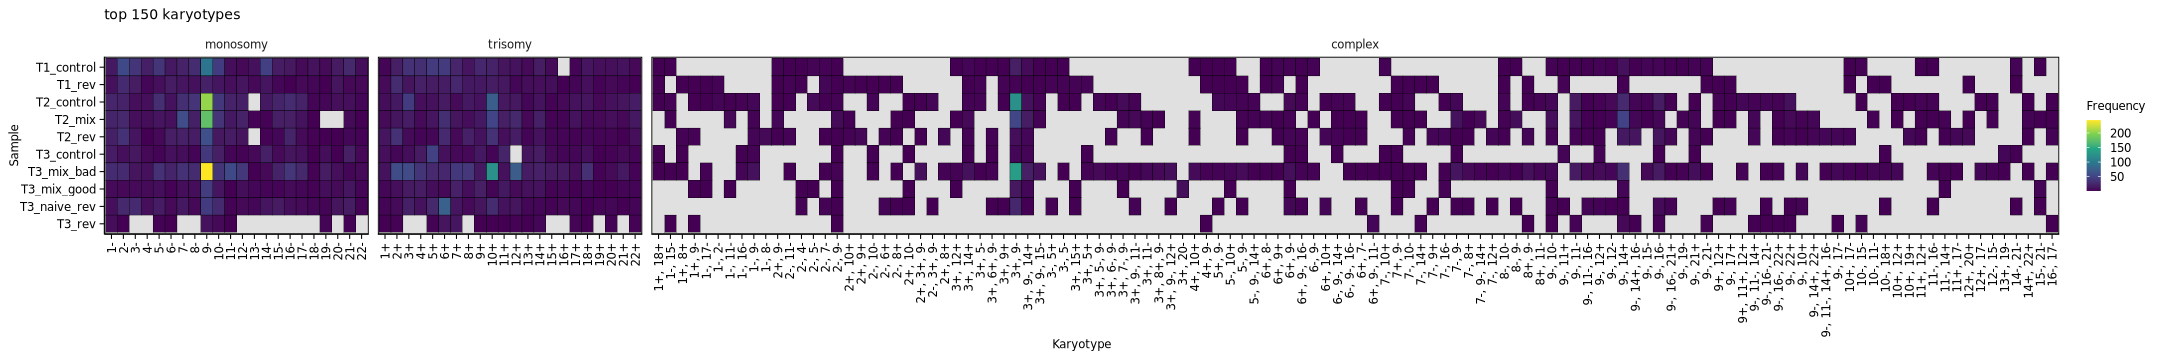

In [34]:
title = "E_heatmap_karyotype_sample_sorted"
w <- 18
h <- 3

options(repr.plot.width=w, repr.plot.height=h)

heatmap_data_filtered$ploidy <- factor(
  heatmap_data_filtered$ploidy, 
  levels = c("monosomy", "trisomy", "complex")
)

gggeom = ggplot(heatmap_data_filtered, aes(x = karyotype, y = sample, fill = count)) +
  geom_tile(color = "black") + 
  scale_fill_viridis_c(option = "viridis") +
  labs(x = "Karyotype", y = "Sample", fill = "Frequency", title = "top 150 karyotypes") +
scale_y_discrete(limits = rev) +
 settheme+
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"), panel.grid = element_blank())+
facet_grid(~ploidy, scales = "free_x", space = "free_x") 

ggsave(plot = gggeom, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gggeom

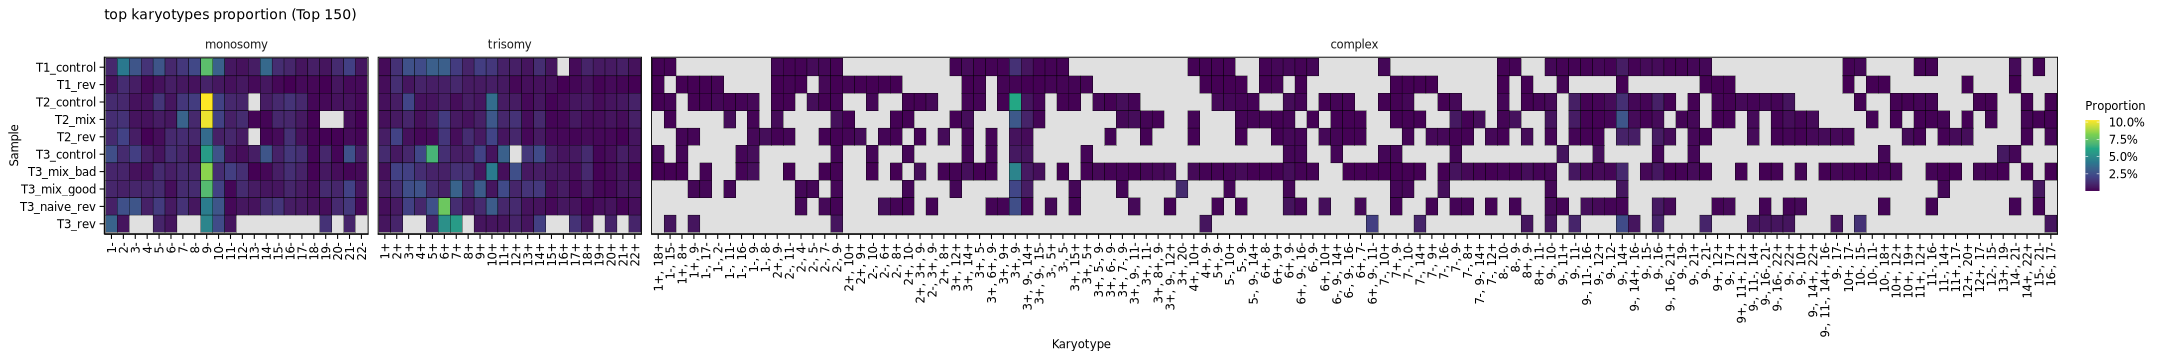

In [35]:
# plot proportions
title = "E_2_heatmap_karyotype_sample_proportion"
w <- 18
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

heatmap_data_filtered$ploidy <- factor(
  heatmap_data_filtered$ploidy, 
  levels = c("monosomy", "trisomy", "complex")
)

gggeom = ggplot(heatmap_data_filtered, aes(x = karyotype, y = sample, fill = prop)) +
  geom_tile(color = "black") + 
  scale_fill_viridis_c(
    option = "viridis", 
    labels = scales::percent, 
    na.value = "#E0E0E0"
  ) +
  labs(x = "Karyotype", y = "Sample", fill = "Proportion", title = "top karyotypes proportion (Top 150)") +
  scale_y_discrete(limits = rev) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"), 
    panel.grid = element_blank()
  )+
facet_grid(~ploidy, scales = "free_x", space = "free_x") 

ggsave(plot = gggeom, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gggeom

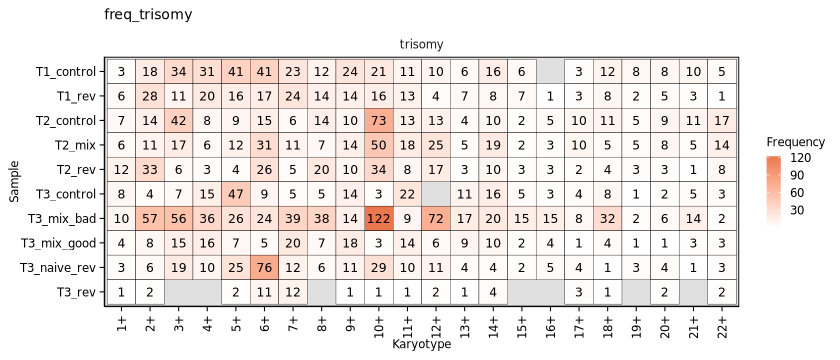

In [36]:
title <- "E3_heatmap_trisomy"
w <- 7
h <- 3
options(repr.plot.width = w, repr.plot.height = h)

# 1) subset ploidy
heatmap_data_filtered2 <- heatmap_data_filtered %>%
  filter(ploidy %in% c("trisomy")) 

gggeom <- ggplot(heatmap_data_filtered2, aes(x = karyotype, y = sample, fill = count)) +
  geom_tile(color = "black") +
  # 2) show numbers in each box
  geom_text(aes(label = count), size = 2.6) +  # Add white borders between tiles
  scale_fill_gradient(low = "white", high = "#EB784D") +
  #scale_fill_viridis_c(option = "viridis") +
  labs(x = "Karyotype", y = "Sample", fill = "Frequency", title = "freq_trisomy") +
  scale_y_discrete(limits = rev) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"),
    panel.grid = element_blank(),
    panel.border = element_blank()
  ) +
  facet_grid(~ploidy, scales = "free_x", space = "free_x")

ggsave(
  filename = sprintf("%s/%s.pdf", outdir, title),
  plot = gggeom,
  width = w, height = h
)

gggeom

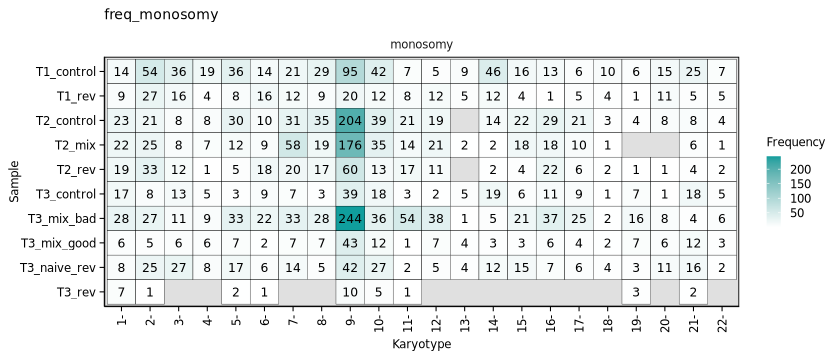

In [37]:
title <- "E4_heatmap_monosomy"
w <- 7
h <- 3
options(repr.plot.width = w, repr.plot.height = h)

# 1) subset ploidy
heatmap_data_filtered2 <- heatmap_data_filtered %>%
  filter(ploidy %in% c("monosomy")) 

gggeom <- ggplot(heatmap_data_filtered2, aes(x = karyotype, y = sample, fill = count)) +
  geom_tile(color = "black") +
  # 2) show numbers in each box
  geom_text(aes(label = count), size = 2.6) +  # Add white borders between tiles
  scale_fill_gradient(low = "white", high = "#109E9D") +
  #scale_fill_viridis_c(option = "viridis") +
  labs(x = "Karyotype", y = "Sample", fill = "Frequency", title = "freq_monosomy") +
  scale_y_discrete(limits = rev) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"),
    panel.grid = element_blank(),
    panel.border = element_blank()
  ) +
  facet_grid(~ploidy, scales = "free_x", space = "free_x")

ggsave(
  filename = sprintf("%s/%s.pdf", outdir, title),
  plot = gggeom,
  width = w, height = h
)

gggeom

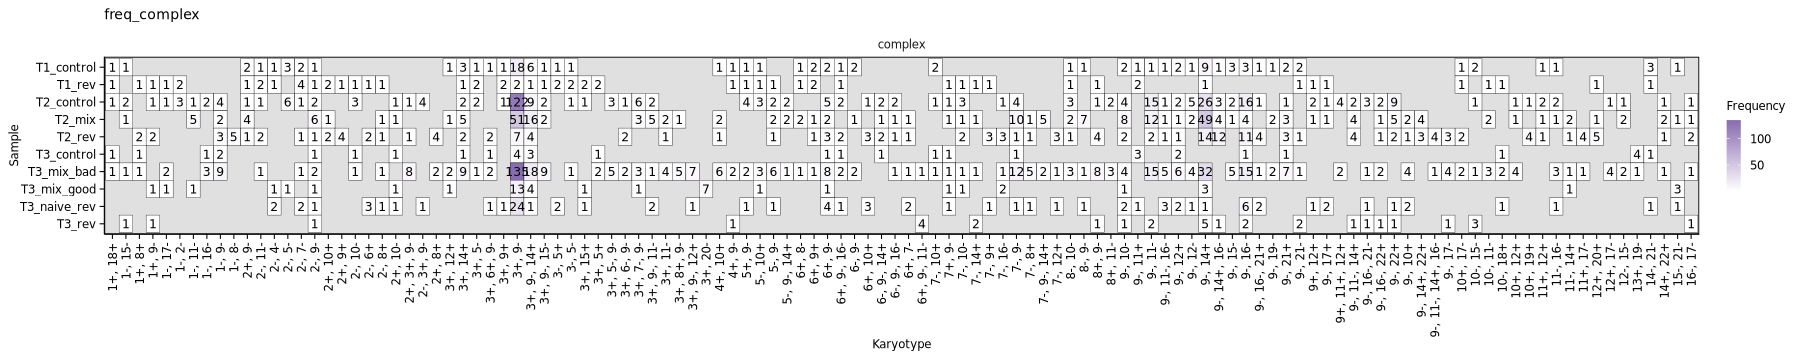

In [38]:
title <- "E5_heatmap_complex"
w <- 15
h <- 3
options(repr.plot.width = w, repr.plot.height = h)

# 1) subset ploidy
heatmap_data_filtered2 <- heatmap_data_filtered %>%
  filter(ploidy %in% c("complex")) 

gggeom <- ggplot(heatmap_data_filtered2, aes(x = karyotype, y = sample, fill = count)) +
  geom_tile(color = "black") +
  # 2) show numbers in each box
  geom_text(aes(label = count), size = 2.6) +  # Add white borders between tiles
  scale_fill_gradient(low = "white", high = "#886DB0") +
  #scale_fill_viridis_c(option = "viridis") +
  labs(x = "Karyotype", y = "Sample", fill = "Frequency", title = "freq_complex") +
  scale_y_discrete(limits = rev) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"),
    panel.grid = element_blank(),
    panel.border = element_blank()
  ) +
  facet_grid(~ploidy, scales = "free_x", space = "free_x")

ggsave(
  filename = sprintf("%s/%s.pdf", outdir, title),
  plot = gggeom,
  width = w, height = h
)

gggeom

### F) Barchart of proportion of each karyotype

In [39]:
head(merged_cellkaryotype_counts,3)

sample,karyotype,ploidy,count,prop
<chr>,<chr>,<chr>,<int>,<dbl>
T1_control,1+,trisomy,3,0.0022900763
T1_control,"1+, 11+",complex,1,0.0007633588
T1_control,"1+, 16+",complex,1,0.0007633588


In [40]:
#percentage of cells per ploidy group
per_ploidy = 
merged_cellkaryotype_counts %>%
  filter(ploidy %in% c("monosomy", "trisomy"))%>%
  group_by(sample)%>%
  mutate(per = count / sum(count)) %>%
  mutate(total =sum(count))

head(per_ploidy)

sample,karyotype,ploidy,count,prop,per,total
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>
T1_control,1+,trisomy,3,0.002290076,0.003456221,868
T1_control,1-,monosomy,14,0.010687023,0.016129032,868
T1_control,10+,trisomy,21,0.016030534,0.024193548,868
T1_control,10-,monosomy,42,0.032061069,0.048387097,868
T1_control,11+,trisomy,11,0.008396947,0.012672811,868
T1_control,11-,monosomy,7,0.005343511,0.008064516,868


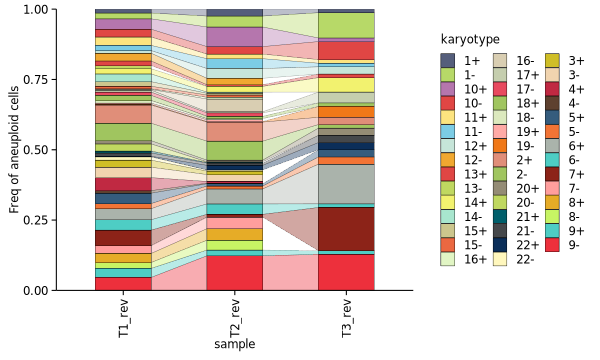

In [41]:
plot_data <- per_ploidy %>%
  ungroup() %>%
  filter(!is.na(per) & !is.na(sample) & !is.na(karyotype)) %>%
  mutate(
    sample = as.factor(sample),
    karyotype = as.factor(karyotype)
  )%>%
  filter(sample %in% c("T1_rev", "T2_rev", "T3_rev"))

# --- Configuration ---
title <- "F_allu_monosomy_trisomy"
w <- 5
h <- 3
options(repr.plot.width = w, repr.plot.height = h)

ggbar_alluvial <- ggplot(plot_data, aes(x = sample, y = per, alluvium = karyotype)) +
  geom_flow(aes(fill = karyotype), alpha = 0.4, curve_type = "linear", width = 0.5 ,linewidth = 0.1, color = "black") +
  geom_stratum(aes(stratum = karyotype, fill = karyotype), width = 0.5, color = "black", linewidth = 0.1) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  labs(y = "Freq of aneuploid cells")  +
  scale_fill_manual(values = custom_palette)+ 
  settheme+
  theme(
    axis.text.x = element_text(colour = "black", angle = 90, vjust = 0.5, hjust = 1)
    #legend.position = "none"
  )

ggsave(plot = ggbar_alluvial, filename = sprintf("%s/%s.pdf", outdir, title), w = w, h = h)
ggbar_alluvial

## include per embryo and cell type analysis

In [42]:
ploidydf = read.csv("/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/ploidydf.csv")
cell_karyotype = read.csv("/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/cell_karyotype_scploid.csv")
scanpy_meta = read.csv( "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/3_scanpy_integration/meta_integrated_sub_fine.csv")
BC_df = read.csv('/nfs/team292/rs40/projects/Aneuploid_screen/processed_data/barcode/BC_df.csv')

## Reformat

In [43]:
head(ploidydf,3)

,chr,cell,z,score,p,p.adj,monosomy,ploidy
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
1,1,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.007713042,0.9976855,0.9938460,1.0000000,TRUE,normal
2,10,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.722146042,0.9367999,0.4702108,0.9910863,TRUE,normal
3,11,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1.896537105,1.1236714,0.0578994,0.3990391,FALSE,normal


In [44]:
head(cell_karyotype, 3)

,X,cell,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr
,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
1,1,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,13+,trisomy,1,0,45,1
2,2,AAACCTGAGATCGGGT-1_Embryo-Imp15265944,16-,monosomy,0,1,43,1
3,3,AAACCTGAGCCGATTT-1_Embryo-Imp15265941,"3+, 4+, 15-, 16-, 17-",complex,2,3,43,5


In [45]:
head(scanpy_meta, 3)

,X,dataset,cell.ID_,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,0,Embryo-Imp15265938,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.29107126,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
2,3,Embryo-Imp15265938,AAACCTGCAATCACAC-1_Embryo-Imp15265938,0.19064748,False,0.19851577,0.5055552,1,0.8326981,8112,54075,1514,2.799815,13757,25.44059,high,-0.04671824,0.36545115,G2M,0,-3.2758442,EPI,EPI,T1_control,day1,Control,Naïve,8112,0.2379417,0,0,2,4,naive EPI,1,EPI_1,EPI
3,5,Embryo-Imp15265938,AAACCTGCAGCTGCTG-1_Embryo-Imp15265938,0.22540984,False,0.22540984,0.7677861,1,0.8326981,8801,68329,1605,2.348929,17109,25.03915,high,-0.04435138,0.21209913,G2M,0,-4.6309091,EPI,EPI,T1_control,day1,Control,Naïve,8801,0.2474431,0,0,3,1,naive EPI,1,EPI_1,EPI


In [46]:
head(BC_df, 3)

,X,cell.ID_,num_features,feature_call,num_umis,dataset,filtered_feature_call
,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,1,AAGGTTCCAGCCACCA,1,pooled_BC_1,490,Embryo-Imp15265940,pooled_BC_1
2,2,CACACAACAAGGACAC,1,pooled_BC_1,2525,Embryo-Imp15265940,pooled_BC_1
3,3,CCTTCCCGTGTGGCTC,1,pooled_BC_1,909,Embryo-Imp15265940,pooled_BC_1


In [47]:
BC_df <- BC_df %>%
  mutate(
    `cell.ID` = paste0(`cell.ID_`, "-1_", dataset)
  )

In [48]:
# create a mergered cellx chr matrix
cell_chr_dfint <- merge(ploidydf, scanpy_meta, 
                     by.x = "cell", 
                     by.y = "cell.ID_", suffixes = c("",".y"),  
                     all.x = TRUE) # all.x = TRUE performs a left join
cell_chr_df <- merge(cell_chr_dfint, BC_df, 
                       by.x = "cell", 
                       by.y = "cell.ID", suffixes = c("",".y"),
                       all.x = TRUE) # all.x = TRUE performs a left join

In [49]:
head(cell_chr_df,3)

,cell,chr,z,score,p,p.adj,monosomy,ploidy,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,X.y,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,13,-1.0581694,0.8513222,0.2899874,0.8904334,TRUE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,21,0.5210107,1.0576815,0.6023635,1.0000000,FALSE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
3,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,9,-0.1908158,1.0215320,0.8486713,1.0000000,TRUE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127


In [50]:
# create a mergered cellx chr matrix
cell_karyo_dfint <- merge(cell_karyotype, scanpy_meta, 
                     by.x = "cell", 
                     by.y = "cell.ID_", suffixes = c("",".y"),  
                     all.x = TRUE) # all.x = TRUE performs a left join
cell_karyo_df <- merge(cell_karyo_dfint, BC_df, 
                       by.x = "cell", 
                       by.y = "cell.ID", suffixes = c("",".y"),
                       all.x = TRUE) |>
                       select(-`X.y`)

Warning message in merge.data.frame(cell_karyo_dfint, BC_df, by.x = "cell", by.y = "cell.ID", :
“column name ‘X.y’ is duplicated in the result”


In [51]:
head(cell_karyo_df,3)

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,25866,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.29044464,0.15769816,S,6,-0.0409680033,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,1,13+,trisomy,1,0,45,1,Embryo-Imp15265942,0.2405063,False,0.2636364,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified,AAACCTGAGACGCTTT,1,pooled_BC_57,284,Embryo-Imp15265942,pooled_BC_57
3,AAACCTGAGAGTCGGT-1_Embryo-Imp15265946,25867,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.2409639,True,0.2263610,1.0691784,1,0.9224943,5816,25038,529,2.112788,6271,25.04593,high,0.02287884,0.20074458,G2M,6,-0.0466536458,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5816,0.3535609,1,1,0,6,unspecified,2,unspecified_1,unspecified,AAACCTGAGAGTCGGT,1,pooled_BC_155,509,Embryo-Imp15265946,pooled_BC_155


In [160]:
#create ploidy_chr and ploidy_cell
cell_chr_karyo_df <- merge(cell_chr_df, cell_karyo_df, 
                       by.x = "cell", 
                       by.y = "cell", suffixes = c("_chr","_cell"),
                       all.x = TRUE) |>
                       select(-`X.y`)

In [161]:
head(cell_chr_karyo_df)

,cell,chr,z,score,p,p.adj,monosomy,ploidy_chr,X_chr,dataset_chr,scrublet_score_chr,scrublet_prediction_chr,scrublet_cluster_score_chr,scrublet_zscore_chr,scrublet_bh_pval_chr,scrublet_bonf_pval_chr,n_genes_by_counts_chr,total_counts_chr,total_counts_mt_chr,pct_counts_mt_chr,total_counts_ribo_chr,pct_counts_ribo_chr,n_genes_group_chr,S_score_chr,G2M_score_chr,phase_chr,leiden_chr,mef_score_chr,persample_celltype_chr,sample_celltype_chr,sample_chr,timepoint_chr,Condition_chr,State_chr,n_genes_chr,stress_score_vandenBrink_chr,leiden_theta0_chr,leiden_theta1_chr,leiden_theta2_chr,leiden_theta3_chr,integrated_celltype_chr,leiden_lowres_chr,celltype_fine_chr,celltype_coarse_chr,cell.ID__chr,num_features_chr,feature_call_chr,num_umis_chr,dataset.y_chr,filtered_feature_call_chr,X_cell,karyotype,ploidy_cell,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset_cell,scrublet_score_cell,scrublet_prediction_cell,scrublet_cluster_score_cell,scrublet_zscore_cell,scrublet_bh_pval_cell,scrublet_bonf_pval_cell,n_genes_by_counts_cell,total_counts_cell,total_counts_mt_cell,pct_counts_mt_cell,total_counts_ribo_cell,pct_counts_ribo_cell,n_genes_group_cell,S_score_cell,G2M_score_cell,phase_cell,leiden_cell,mef_score_cell,persample_celltype_cell,sample_celltype_cell,sample_cell,timepoint_cell,Condition_cell,State_cell,n_genes_cell,stress_score_vandenBrink_cell,leiden_theta0_cell,leiden_theta1_cell,leiden_theta2_cell,leiden_theta3_cell,integrated_celltype_cell,leiden_lowres_cell,celltype_fine_cell,celltype_coarse_cell,cell.ID__cell,num_features_cell,feature_call_cell,num_umis_cell,dataset.y_cell,filtered_feature_call_cell
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,13,-1.05816939,0.8513222,0.2899874,0.8904334,TRUE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,25866,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,21,0.52101068,1.0576815,0.6023635,1.0000000,FALSE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,25866,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
3,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,9,-0.19081584,1.0215320,0.8486713,1.0000000,TRUE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.0409

### G) % aneuploid per condition (per embryo)

In [52]:
#Compute per embryo summary

cell_karyo_summary_df <- cell_karyo_df |>

  group_by(sample, dataset, timepoint, Condition, filtered_feature_call) |>

  summarise(

    total = n(), 
    
    n_monosomy = sum(ploidy == "monosomy", na.rm = TRUE),
    n_trisomy  = sum(ploidy == "trisomy", na.rm = TRUE),
    n_complex  = sum(ploidy == "complex", na.rm = TRUE),
    n_aneuploid = sum(ploidy != "diploid", na.rm = TRUE),
    
    per_monosomy = if_else(total > 0, n_monosomy / total, 0),
    per_trisomy = if_else(total > 0, n_trisomy / total, 0),
    per_complex = if_else(total > 0, n_complex / total, 0),
    per_aneuploid = if_else(total > 0, n_aneuploid / total, 0),
    
    .groups = "drop" 
  )|>
  filter(
    !is.na(filtered_feature_call) & # 1. Remove rows where the column is NA
    filtered_feature_call != "fail"  # 2. Remove rows where the value is "fail"
  )

head(cell_karyo_summary_df)

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,per_monosomy,per_trisomy,per_complex,per_aneuploid
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,3,0,3,6,0.37500000,0.00000000,0.37500000,0.7500000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_10,21,1,0,3,4,0.04761905,0.00000000,0.14285714,0.1904762
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_100,34,7,5,13,25,0.20588235,0.14705882,0.38235294,0.7352941
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_101,72,10,4,7,21,0.13888889,0.05555556,0.09722222,0.2916667
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_102,7,2,0,0,2,0.28571429,0.00000000,0.00000000,0.2857143
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_104,45,2,2,8,12,0.04444444,0.04444444,0.17777778,0.2666667


In [53]:
#Convert to long form 

cell_karyo_long_df <- cell_karyo_summary_df |>
  pivot_longer(
    cols = c(per_monosomy, per_trisomy, per_complex, per_aneuploid),
    names_to = "ploidy",
    values_to = "per"
  ) |>
  mutate(
    ploidy = ploidy |>
      stringr::str_replace("per_", "")
  )


In [54]:
head(cell_karyo_long_df )

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,ploidy,per
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,3,0,3,6,monosomy,0.37500000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,3,0,3,6,trisomy,0.00000000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,3,0,3,6,complex,0.37500000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,3,0,3,6,aneuploid,0.75000000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_10,21,1,0,3,4,monosomy,0.04761905
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_10,21,1,0,3,4,trisomy,0.00000000


Warning message:
“Removed 533 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 525 rows containing missing values or values outside the scale range
(`geom_point()`).”


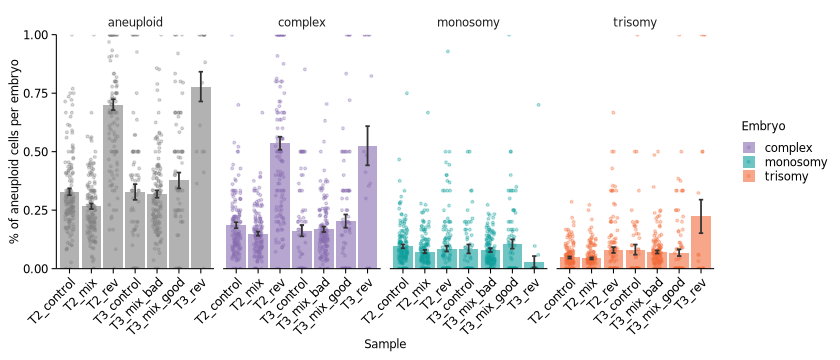

In [55]:
title = "A_per_ploidy_structure"

w <- 7
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

ggbar = ggplot(cell_karyo_long_df, aes(x = sample, y = per, fill = ploidy)) +
  geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.5, width = 0.2, alpha = 0.3, aes(color = ploidy))+
stat_summary(fun.data = "mean_se", geom = "errorbar", width = 0.2, color = "grey20") +
  
  # Labels and theme
  labs(
    x = "Sample",
    y = "% of aneuploid cells per embryo",
    fill = "Embryo",
    color = "Embryo"
  ) +
  settheme +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
 facet_wrap(~ploidy, ncol = 4)+
 scale_fill_manual(values=color_ploidy)+
 scale_color_manual(values=color_ploidy)

ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

### H) % aneuploid per cell type

In [56]:
#summarise
cell_karyo_df_summary <- cell_karyo_df%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )%>%
  mutate(ploidy = factor(ploidy , levels = c("diploid", "monosomy", "trisomy", "complex"))) %>%
  group_by(filtered_feature_call, sample, celltype_coarse, ploidy,.drop = FALSE) %>%
  summarise(count = n()) %>%
  mutate(sum = sum(count)) %>%
  #filter(sum(count) >= 10) %>%
  mutate(percentage = count / sum(count)) %>%
  ungroup()%>% 
  filter(ploidy != "diploid")

`summarise()` has grouped output by 'filtered_feature_call', 'sample',
'celltype_coarse'. You can override using the `.groups` argument.


In [57]:
# 1) base summary (non-diploid), with sum computed BEFORE adding "aneuploid"
base <- cell_karyo_df %>%
  filter(!is.na(ploidy),
         !is.na(filtered_feature_call),
         filtered_feature_call != "fail") %>%
  mutate(ploidy = factor(ploidy, levels = c("diploid","monosomy","trisomy","complex"))) %>%
  group_by(filtered_feature_call, sample, celltype_coarse, ploidy, .drop = FALSE) %>%
  summarise(count = n(), .groups = "drop_last") %>%
  ungroup() %>%
  group_by(filtered_feature_call, sample, celltype_coarse) %>%
  mutate(sum = sum(count)) %>%   # denominator across monosomy/trisomy/complex only
  ungroup() %>%
  mutate(percentage = count / sum)  %>%
  filter(ploidy != "diploid") %>%
  filter(sum >= 5) 

# 2) add "aneuploid" level: count = sum across monosomy+trisomy+complex
aneu <- base %>%
  group_by(filtered_feature_call, sample, celltype_coarse) %>%
  summarise(
    ploidy = "aneuploid",
    count  = sum(count),
    sum    = first(sum),        # keep the original denominator
    .groups = "drop"
  ) %>%
  mutate(percentage = count / sum)

# 3) bind + set factor levels
cell_karyo_df_summary <- bind_rows(base, aneu) %>%
  mutate(ploidy = factor(ploidy,
                         levels = c("aneuploid", "monosomy","trisomy","complex")))


Warning message:
“Removed 215 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 191 rows containing missing values or values outside the scale range
(`geom_point()`).”


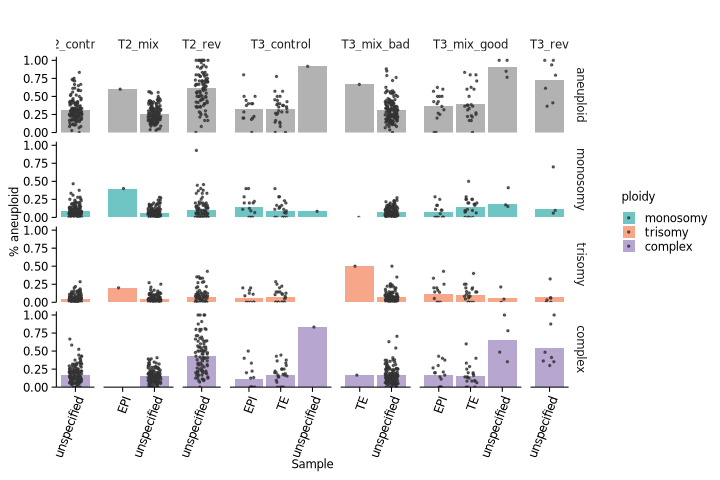

In [58]:
#plot
title = "B_bar_celltype_ploidy_sample"

#df_summary = df_summary%>%
   # filter(sample %in% c("T2_mix", "T2_rev", "T3_rev", "T3_mix_bad", "T3_mix_good", "T3_naive_rev"))

w <- 6
h <- 4
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary, aes(x = celltype_coarse ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 1.05)) +
theme(axis.text.x = element_text(colour = "black", angle = 70, hjust = 1))+
  labs(title = "",
       x = "Sample",
       y = "% aneuploid") +
facet_grid(ploidy ~ sample, scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

In [60]:
#plot
title = "B_bar_celltype_ploidy_sample"

cell_karyo_df_summary_sub = cell_karyo_df_summary%>%
    filter(sample %in% c("T3_control", "T3_rev", "T3_mix_bad", "T3_mix_good"))

w <- 7
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary_sub, aes(x = celltype_coarse ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 1.05)) +
theme(axis.text.x = element_text(colour = "black", angle = 70,  vjust=1.1,  hjust = 1.0))+
  labs(title = "",
       x = "Sample",
       y = "prop aneuploid") +
facet_wrap(ploidy ~ sample, scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

ERROR: Error in facet_wrap(ploidy ~ sample, scales = "free_x", space = "free_x"): unused argument (space = "free_x")


In [61]:
#plot
title = "B_bar_celltype_ploidy_T3mix"

cell_karyo_df_summary_sub = cell_karyo_df_summary%>%
    filter(sample %in% c("T3_mix_good"))

w <- 4
h <- 2.5
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary_sub, aes(x = celltype_coarse ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 1.05)) +
theme(axis.text.x = element_text(colour = "black", angle = 70,  vjust=1.1,  hjust = 1.0))+
  labs(title = "T3_mix",
       x = "Sample",
       y = "prop aneuploid") +
facet_wrap( ~ ploidy , scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

ERROR: Error in facet_wrap(~ploidy, scales = "free_x", space = "free_x"): unused argument (space = "free_x")


In [62]:
cell_karyo_df_summary_sub %>%
  group_by(ploidy) %>%
  pairwise_wilcox_test(
    percentage ~ celltype_coarse,
    p.adjust.method = "none"
  ) 

,ploidy,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<fct>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,aneuploid,percentage,EPI,TE,16,24,194.5,0.956,0.956,ns
2,aneuploid,percentage,EPI,unspecified,16,4,0.0,0.003,0.003,**
3,aneuploid,percentage,TE,unspecified,24,4,3.0,0.003,0.003,**
4,monosomy,percentage,EPI,TE,16,24,131.0,0.087,0.087,ns
5,monosomy,percentage,EPI,unspecified,16,4,18.0,0.181,0.181,ns
6,monosomy,percentage,TE,unspecified,24,4,45.0,0.868,0.868,ns
7,trisomy,percentage,EPI,TE,16,24,195.0,0.943,0.943,ns
8,trisomy,percentage,EPI,unspecified,16,4,37.0,0.656,0.656,ns
9,trisomy,percentage,TE,unspecified,24,4,59.0,0.480,0.480,ns


### I) % aneuploid per cell type_fine

In [63]:
#summarise
cell_karyo_df_summary <- cell_karyo_df%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )%>%
  mutate(ploidy = factor(ploidy , levels = c("diploid", "monosomy", "trisomy", "complex"))) %>%
  group_by(filtered_feature_call, sample, celltype_fine, ploidy,.drop = FALSE) %>%
  summarise(count = n()) %>%
  mutate(sum = sum(count)) %>%
  #filter(sum(count) >= 10) %>%
  mutate(percentage = count / sum(count) * 100) %>%
  ungroup()%>% 
  filter(ploidy != "diploid")

`summarise()` has grouped output by 'filtered_feature_call', 'sample',
'celltype_fine'. You can override using the `.groups` argument.


Warning message:
“Removed 1086 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1074 rows containing missing values or values outside the scale range
(`geom_point()`).”


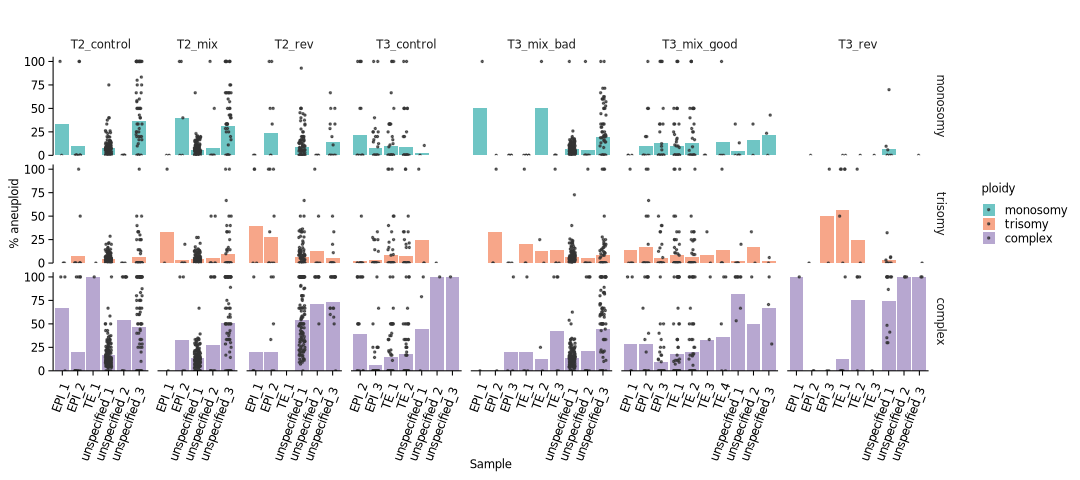

In [64]:
#plot``
title = "C_bar_celltype_ploidy_fine"

#df_summary = df_summary%>%
   # filter(sample %in% c("T2_mix", "T2_rev", "T3_rev", "T3_mix_bad", "T3_mix_good", "T3_naive_rev"))

w <- 9
h <- 4
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary, aes(x = celltype_fine ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 105)) +
theme(axis.text.x = element_text(colour = "black", angle = 70, hjust = 1.1))+
  labs(title = "",
       x = "Sample",
       y = "% aneuploid") +
facet_grid(ploidy ~ sample, scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

Warning message:
“Removed 651 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 692 rows containing missing values or values outside the scale range
(`geom_point()`).”


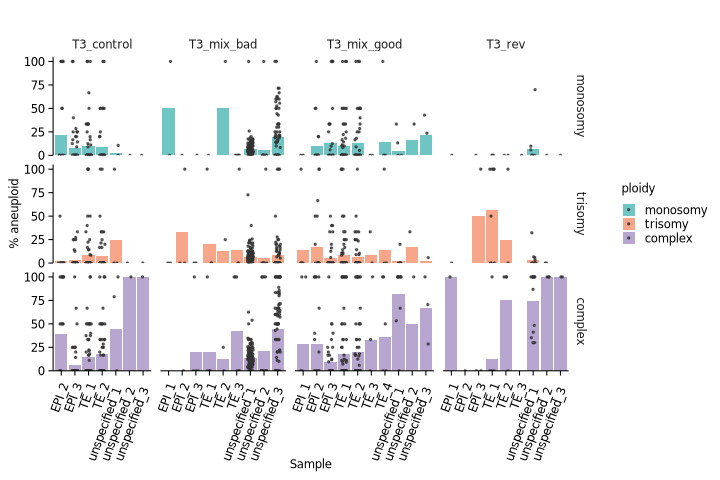

In [65]:
#plot``
title = "C2_bar_celltype_ploidy_fine"

cell_karyo_df_summary_sub = cell_karyo_df_summary%>%
    filter(sample %in% c("T3_control", "T3_rev", "T3_mix_bad", "T3_mix_good"))

w <- 6
h <- 4
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary_sub, aes(x = celltype_fine ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 105)) +
theme(axis.text.x = element_text(colour = "black", angle = 70, hjust = 1.1))+
  labs(title = "",
       x = "Sample",
       y = "% aneuploid") +
facet_grid(ploidy ~ sample, scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

### J) time course

In [66]:
#recompute to include the timepoint1 sample

cell_karyo_summary_df <- cell_karyo_df |>
   filter(!(timepoint == "day4" & filtered_feature_call == "fail")) |>
   filter(!(timepoint == "day6" & filtered_feature_call == "fail"))|>
  group_by(sample, dataset, timepoint, Condition, filtered_feature_call) |>

  summarise(

    total = n(), 
    
    n_monosomy = sum(ploidy == "monosomy", na.rm = TRUE),
    n_trisomy  = sum(ploidy == "trisomy", na.rm = TRUE),
    n_complex  = sum(ploidy == "complex", na.rm = TRUE),
    n_aneuploid = sum(ploidy != "diploid", na.rm = TRUE),
    
    per_monosomy = if_else(total > 0, n_monosomy / total, 0),
    per_trisomy = if_else(total > 0, n_trisomy / total, 0),
    per_complex = if_else(total > 0, n_complex / total, 0),
    per_aneuploid = if_else(total > 0, n_aneuploid / total, 0),
    
    .groups = "drop" 
  ) |>
  filter(total > 5)

cell_karyo_long_df <- cell_karyo_summary_df |>
  pivot_longer(
    cols = c(per_monosomy, per_trisomy, per_complex, per_aneuploid),
    names_to = "ploidy",
    values_to = "per"
  ) |>
  mutate(
    ploidy = ploidy |>
      stringr::str_replace("per_", "")
  )

order = c('aneuploid','monosomy','trisomy','complex')
cell_karyo_long_df$ploidy <- factor(cell_karyo_long_df$ploidy , levels = order)
  

In [67]:
#to start the CI from the first time point
my_mean_ci <- function(x, conf.int = 0.95, R = 1000) {
  # If only ONE data point, return that point with zero CI.
  # If multiple points, do a "mean_cl_boot"-like calculation.

  # 0) How many data points do we have in 'x'?
  n <- length(na.omit(x))
  
  if (n == 1) {
    # Use the single point for y, and 0 range for ymin,ymax
    m <- x[!is.na(x)]
    return(data.frame(y = m, ymin = m, ymax = m))
  } else if (n > 1) {
    # We can mimic ggplot2’s "mean_cl_boot" approach or Hmisc::smean.cl.boot
    # Here is a simple example using Hmisc:
    library(Hmisc)
    b <- smean.cl.boot(x, conf.int = conf.int, B = R) 
    # smean.cl.boot returns (Mean, Lower, Upper)
    # so we just reformat into y, ymin, ymax
    return(data.frame(y = b[1], ymin = b[2], ymax = b[3]))
  } else {
    # If no valid data, return all NA
    return(data.frame(y = NA, ymin = NA, ymax = NA))
  }
}

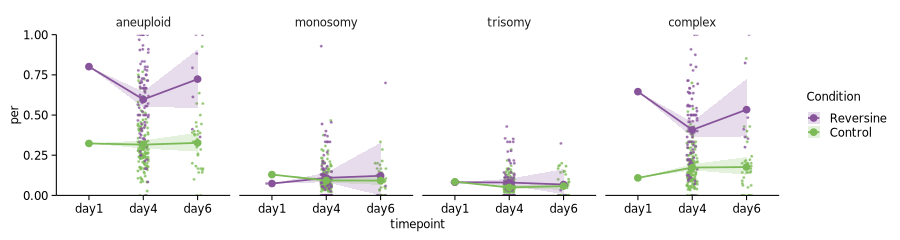

In [68]:
# Plot using ggplot2
title = "J_timecourse_jitter"

w <- 7.5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("Reversine","Control", "Mosaic")
cell_karyo_long_df$Condition <- factor(cell_karyo_long_df$Condition , levels = order)


cell_karyo_long_df_sub = cell_karyo_long_df %>%
    subset(Condition %in% c("Reversine","Control"))

gg = ggplot(cell_karyo_long_df_sub, aes(x = timepoint, y = per, color = Condition, fill = Condition, group = Condition)) +
  # 4. Raw data points (directly plotted)
  geom_point(
    # Typically you don't re-specify color/fill mapping here
    # unless you want a different aesthetic. 
    # You can also use position_jitter or position_dodge if needed:
    position = position_jitter(width = 0.1, height = 0),
    alpha = 0.6, 
    size = 0.2
  ) +
  # 1. Ribbon for CI (0-width if only 1 datapoint)
  stat_summary(
    fun.data = my_mean_ci,  # Custom function from previous example
    geom = "ribbon",
    alpha = 0.2,
    color = NA
  ) +
  # 2. Line for the mean
  stat_summary(
    fun.data = my_mean_ci,
    geom = "line"
  ) +
  # 3. Mean point
  stat_summary(
    fun.data = my_mean_ci,
    geom = "point"
  ) +
  facet_grid(~ ploidy) +
  scale_color_manual(values = color_condition) +
  scale_fill_manual(values = color_condition) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5)
  )+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  theme(
    # increase vertical (y) spacing between panels
    panel.spacing.y = unit(0.5, "cm")
  )
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg

In [69]:
#add the point for mosaic 
day1mid_df <- cell_karyo_long_df_sub %>%
  filter(timepoint == "day1", Condition %in% c("Reversine","Control")) %>%
  group_by(ploidy) %>%
  summarise(per = mean(per, na.rm = TRUE), .groups = "drop") %>%
  mutate(x_mid = 1)  # exactly at the first timepoint center
day1mid_df 

ploidy,per,x_mid
<fct>,<dbl>,<dbl>
aneuploid,0.56225854,1
monosomy,0.10174013,1
trisomy,0.08322898,1
complex,0.37728944,1


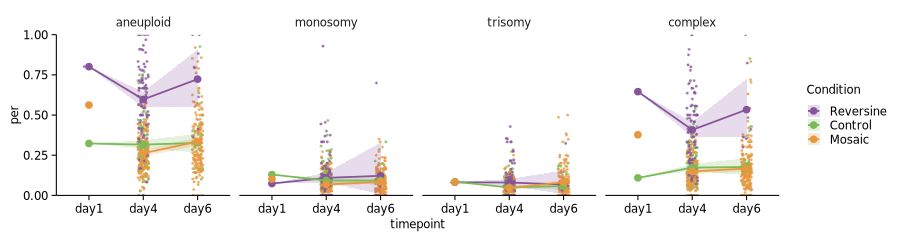

In [70]:
# Plot using ggplot2
title = "J_timecourse_jitter_with_mosaic"

w <- 7.5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("Reversine","Control", "Mosaic")
cell_karyo_long_df$Condition <- factor(cell_karyo_long_df$Condition , levels = order)

cell_karyo_long_df_sub = cell_karyo_long_df %>%
    subset(Condition %in% c("Reversine","Control","Mosaic"))

gg = ggplot(cell_karyo_long_df_sub, aes(x = timepoint, y = per, color = Condition, fill = Condition, group = Condition))  +
  # 4. Raw data points (directly plotted)
  geom_point(
    # Typically you don't re-specify color/fill mapping here
    # unless you want a different aesthetic. 
    # You can also use position_jitter or position_dodge if needed:
    position = position_jitter(width = 0.1, height = 0),
    alpha = 0.6, 
    size = 0.2
  ) +
  # 1. Ribbon for CI (0-width if only 1 datapoint)
  stat_summary(
    fun.data = my_mean_ci,  # Custom function from previous example
    geom = "ribbon",
    alpha = 0.2,
    color = NA
  ) +
  # 2. Line for the mean
  stat_summary(
    fun.data = my_mean_ci,
    geom = "line"
  ) +
  # 3. Mean point
  stat_summary(
    fun.data = my_mean_ci,
    geom = "point"
  )+
  facet_grid(~ ploidy) +
  scale_color_manual(values = color_condition) +
  scale_fill_manual(values = color_condition) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5)
  )+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  theme(
    # increase vertical (y) spacing between panels
    panel.spacing.y = unit(0.5, "cm")
  )+
  geom_point(
    data = day1mid_df,
    aes(x = x_mid, y = per),
    inherit.aes = FALSE,
    color = "#E8973E"
    #size = 0.5
  ) 

ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg

In [71]:
unique(cell_karyo_long_df$Condition)

[1] Control   Reversine Mosaic   
Levels: Reversine Control Mosaic

In [72]:
eps <- 1e-6

log_fc <- cell_karyo_long_df_sub %>%
  filter(timepoint %in% c("day1", "day6")) %>%
  group_by(Condition, ploidy, timepoint) %>%
  summarise(mean_per = mean(per, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = timepoint, values_from = mean_per) %>%
  mutate(log_ratio_day6_day1 = log((day6 + eps) / (day1 + eps))) %>%
  select(Condition, ploidy, log_ratio_day6_day1)

log_fc 

Condition,ploidy,log_ratio_day6_day1
<fct>,<fct>,<dbl>
Reversine,aneuploid,-0.10198055
Reversine,monosomy,0.50297440
Reversine,trisomy,-0.19027382
Reversine,complex,-0.19022840
Control,aneuploid,0.01080292
Control,monosomy,-0.33811255
Control,trisomy,-0.37941083
Control,complex,0.48116906
Mosaic,aneuploid,NA


Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_summary()`).”


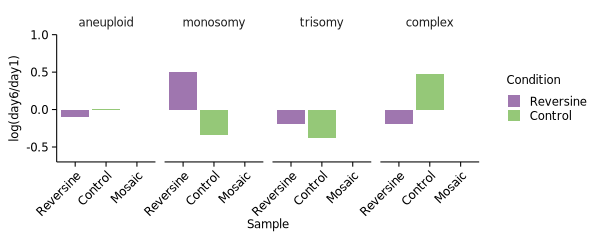

In [73]:
title = "J2_bar"

w <- 5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

ggbar = ggplot(log_fc , aes(x = Condition, y = log_ratio_day6_day1, fill = Condition)) +
  geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.8)+
  
  # Labels and theme
  labs(
    x = "Sample",
    y = "log(day6/day1)"
  ) +
  settheme +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
 scale_y_continuous(expand = c(0, 0), limits = c(-0.7, 1)) +
 facet_wrap(~ploidy, ncol = 4)+
  scale_fill_manual(values = color_condition) 

ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

### K) Line graph norm log(prop)

In [74]:
screen_counts <- merged_ploidydf %>%
  group_by(chr, ploidy, sample)%>%
  summarise(count= n(), .groups = "drop")
head(screen_counts)

chr,ploidy,sample,count
<int>,<fct>,<chr>,<int>
1,normal,T1_control,3965
1,normal,T1_rev,1998
1,normal,T2_control,6149
1,normal,T2_mix,6158
1,normal,T2_rev,2209
1,normal,T3_control,2271


In [75]:
ref_ploidy <- "normal"
pc <- 0.5

logprop_df <- screen_counts %>%
  group_by(chr, sample) %>%
  mutate(ref_count = count[ploidy == ref_ploidy][1]) %>%
  ungroup() %>%
  filter(ploidy != ref_ploidy) %>%
  mutate(alr = log((count + pc) / (ref_count + pc)))

1. monosomy

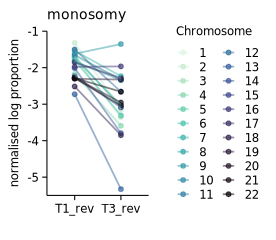

In [76]:
# Subset the data to include only T3_naive_rev and T3_rev
monosomy_subset <- logprop_df %>%
  filter(sample %in% c("T1_rev",  "T3_rev"))%>%
  filter(ploidy == "monosomy")

monosomy_subset$chr <- as.factor(monosomy_subset$chr)
 

# Define plot title and dimensions
title <- "K1_norm_log_prop_mono"
w <- 2.3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# Plot
gg <- ggplot(monosomy_subset, aes(x = sample, y = alr, color = chr, group = chr)) +
  geom_point(size = 1, alpha = 0.7) +
  geom_line(aes(group = chr), alpha = 0.5) +  # Connect points by chromosome
  theme_minimal() +
  labs(
    title = "monosomy",
    x = "",
    y = "normalised log proportion",
    color = "Chromosome"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.minor = element_blank()
  ) +
  scale_color_manual(values = col_monosomy)+settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(-5.5, -1))

# Save plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)

gg

2. trisomy

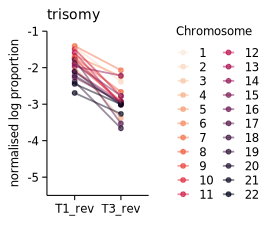

In [77]:
# Subset the data to include only T3_naive_rev and T3_rev
trisomy_subset <- logprop_df %>%
  filter(sample %in% c("T1_rev",  "T3_rev"))%>%
  filter(ploidy == "trisomy")

trisomy_subset$chr <- as.factor(trisomy_subset$chr)
 

# Define plot title and dimensions
title <- "K2_norm_log_prop_trisomy"
w <- 2.3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# Plot
gg <- ggplot(trisomy_subset, aes(x = sample, y = alr, color = chr, group = chr)) +
  geom_point(size = 1, alpha = 0.7) +
  geom_line(aes(group = chr), alpha = 0.5) +  # Connect points by chromosome
  theme_minimal() +
  labs(
    title = "trisomy",
    x = "",
    y = "normalised log proportion",
    color = "Chromosome"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.minor = element_blank()
  ) +
  scale_color_manual(values = col_trisomy)+settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(-5.5, -1))

# Save plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)

gg

### L) bar delta log prop

In [78]:
alr_long <- logprop_df %>%
  select(chr, ploidy, sample, alr) %>%
  filter(sample %in% c("T1_rev", "T3_rev")) %>%
  pivot_wider(names_from = sample, values_from = alr) %>%
  mutate(T3_T1rev = T3_rev - T1_rev) %>%
  select(chr, ploidy, T3_T1rev) %>%
  pivot_longer(
    cols = T3_T1rev,
    names_to = "sample",
    values_to = "alr"
  )

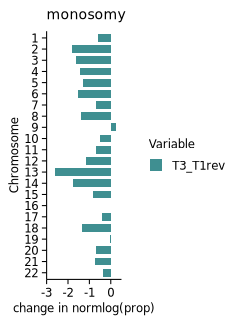

In [79]:
#plot
# Subset the data to include only T3_naive_rev and T3_rev
monosomy_subset <- alr_long %>%
  filter(sample %in% c("T3_T1rev"))%>%
  filter(ploidy == "monosomy")

monosomy_subset$chr <- as.factor(monosomy_subset$chr)
 

title = "L1_bar_logprop_monosomy"

w <- 2
h <- 2.7
options(repr.plot.width=w, repr.plot.height=h)

gg <- ggplot(monosomy_subset, aes(x = alr, y = chr, fill = sample)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "monosomy",
    x = "change in normlog(prop)",
    y = "Chromosome",
    fill = "Variable"
  ) +
  #scale_fill_viridis_d(option = "mako", begin = 0.2, end = 0.8) +
  scale_fill_manual(values =c("#3F8F91"))+
  settheme+
  scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

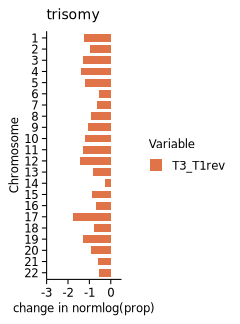

In [80]:
#plot
# Subset the data to include only T3_naive_rev and T3_rev
trisomy_subset <- alr_long %>%
  filter(sample %in% c("T3_T1rev"))%>%
  filter(ploidy == "trisomy")

trisomy_subset$chr <- as.factor(trisomy_subset$chr)
 

title = "L2_bar_logprop_trisomy"

w <- 2
h <- 2.7
options(repr.plot.width=w, repr.plot.height=h)

gg <- ggplot(trisomy_subset, aes(x = alr, y = chr, fill = sample)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "trisomy",
    x = "change in normlog(prop)",
    y = "Chromosome",
    fill = "Variable"
  ) +
  #scale_fill_viridis_d(option = "mako", begin = 0.2, end = 0.8) +
  scale_fill_manual(values =c("#E17348"))+
  settheme+
  scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

### M) Number of abnormal chr against change in prop

In [81]:
ab_counts <- merged_cellkaryotype %>%
  group_by(num_abnormal_chr, sample)%>%
  summarise(count= n(), .groups = "drop")
head(ab_counts)

num_abnormal_chr,sample,count
<int>,<chr>,<int>
0,T1_control,2742
0,T1_rev,554
0,T2_control,4524
0,T2_mix,4729
0,T2_rev,1048
0,T3_control,1661


In [82]:
ref_ploidy = 0
pc <- 0.5

log_ab_counts <- ab_counts %>%
  group_by(sample) %>%
  mutate(ref_count = count[num_abnormal_chr == ref_ploidy][1]) %>%
  ungroup() %>%
  filter(num_abnormal_chr != ref_ploidy) %>%
  mutate(alr = log((count + pc) / (ref_count + pc)))

In [83]:
alr_long <- log_ab_counts %>%
  select(num_abnormal_chr, sample, alr) %>%
  filter(sample %in% c("T1_rev", "T3_rev", "T3_naive_rev")) %>%
  #filter(sample %in% c("T1_rev", "T3_rev", "T3_naive_rev")) %>%
  pivot_wider(names_from = sample, values_from = alr) %>%
  mutate(blastoid = T3_rev - T1_rev, 
         naive = T3_naive_rev - T1_rev) %>%
  select(num_abnormal_chr, blastoid, naive) %>%
  pivot_longer(
      cols = c("blastoid", "naive"), 
    names_to = "sample",
    values_to = "alr"
  )

In [84]:
head(alr_long)

num_abnormal_chr,sample,alr
<int>,<chr>,<dbl>
1,blastoid,-0.12483335
1,naive,-0.86503422
2,blastoid,-0.04023193
2,naive,-1.38094043
3,blastoid,-0.42715647
3,naive,-2.09388457


Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_point()`).”


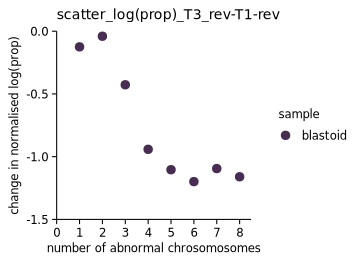

In [85]:
#plot
title = "scatter_log(prop)_T3_rev-T1-rev"

w <- 3
h <- 2.2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(alr_long%>%subset(sample == "blastoid"), aes(x = num_abnormal_chr, y = alr, col = sample)) +
  geom_point(size = 2) +
 # geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  labs(y = "change in normalised log(prop)", 
      x = "number of abnormal chrosomosomes") +
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
scale_color_manual(values=c("naive"= "#714684","blastoid"="#482D53"))+
scale_x_continuous(
  expand = c(0, 0),
  limits = c(0,8.5),
  breaks = seq(0, 8, by = 1))+
scale_y_continuous(
  expand = c(0, 0),
  limits = c(-1.5,0))+  
labs(
    title = title 
   # x = "change in normlog(prop)",
   # y = "Chromosome",
    #fill = "Variable"
  )
                   
ggsave(plot = ggscatter, filename = sprintf("%s/M_%s.pdf",outdir, title), w = w, h = h)
ggscatter

### N) Bar per_ploidy_structure_g_b

In [86]:
cell_karyo_long_df_sub = cell_karyo_long_df%>%
subset(sample %in%c("T3_mix_good", "T3_mix_bad"))


In [87]:
head(cell_karyo_long_df_sub,3)

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,ploidy,per
<chr>,<chr>,<chr>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,<fct>,<dbl>
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,1,0,2,3,monosomy,0.03846154
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,1,0,2,3,trisomy,0.00000000
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,1,0,2,3,complex,0.07692308


Warning message:
“Removed 31 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 33 rows containing missing values or values outside the scale range
(`geom_point()`).”


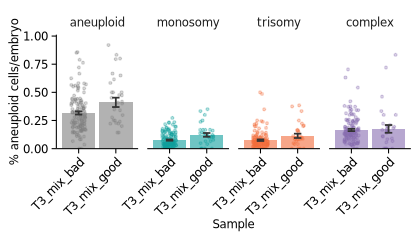

In [88]:
title = "N_per_ploidy_structure_g_b"

w <- 3.5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

ggbar = ggplot(cell_karyo_long_df_sub , aes(x = sample, y = per, fill = ploidy)) +
  geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.5, width = 0.2, alpha = 0.3, aes(color = ploidy))+
stat_summary(fun.data = "mean_se", geom = "errorbar", width = 0.2, color = "grey20") +
  
  # Labels and theme
  labs(
    x = "Sample",
    y = "% aneuploid cells/embryo"
  ) +
  settheme +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none")+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1))) +
 facet_wrap(~ploidy, ncol = 4)+
    scale_fill_manual(values=color_ploidy)+
 scale_color_manual(values=color_ploidy)

ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

In [89]:
cell_karyo_long_df_sub %>%
  group_by(ploidy) %>%
  pairwise_wilcox_test(
    per ~ sample,
    p.adjust.method = "none"
  ) 

,ploidy,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<fct>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,aneuploid,per,T3_mix_bad,T3_mix_good,136,32,1629,0.027,0.027,*
2,monosomy,per,T3_mix_bad,T3_mix_good,136,32,1546,0.011,0.011,*
3,trisomy,per,T3_mix_bad,T3_mix_good,136,32,1718,0.064,0.064,ns
4,complex,per,T3_mix_bad,T3_mix_good,136,32,2321,0.559,0.559,ns


Warning message:
“Removed 28 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 28 rows containing missing values or values outside the scale range
(`geom_point()`).”


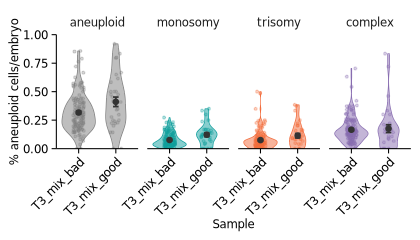

In [90]:
title <- "N2_violin_per_ploidy_structure_g_b"

w <- 3.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

ggbar <- ggplot(
  cell_karyo_long_df_sub,
  aes(x = sample, y = per, fill = ploidy, color = ploidy)
) +
  # violin per sample within each ploidy facet
  geom_violin(
    alpha = 0.5,
    linewidth = 0.2,
    trim = TRUE
  ) +
  # jittered points
  geom_jitter(
    size = 0.5,
    width = 0.15,
    alpha = 0.3,
  aes(color = ploidy)
  ) +
  # mean ± SE
  stat_summary(fun = mean, geom = "point", size = 1.2, colour = "grey20") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.15, colour = "grey20") +
  labs(
    x = "Sample",
    y = "% aneuploid cells/embryo"
  ) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  facet_wrap(~ploidy, ncol = 4)+
    scale_fill_manual(values=color_ploidy)+
 scale_color_manual(values=color_ploidy)

ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)
ggbar


In [91]:
head(cell_karyo_long_df_sub, 3)

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,ploidy,per
<chr>,<chr>,<chr>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,<fct>,<dbl>
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,1,0,2,3,monosomy,0.03846154
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,1,0,2,3,trisomy,0.00000000
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,1,0,2,3,complex,0.07692308


In [92]:
#recompute to include the timepoint1 sample

cell_karyo_summary_df <- cell_karyo_df |>
   filter(!(timepoint == "day4" & filtered_feature_call == "fail")) |>
   filter(!(timepoint == "day6" & filtered_feature_call == "fail"))|>
  group_by(sample, dataset, timepoint, Condition, filtered_feature_call) |>

  summarise(

    total = n(), 
    
    n_monosomy = sum(ploidy == "monosomy", na.rm = TRUE),
    n_trisomy  = sum(ploidy == "trisomy", na.rm = TRUE),
    n_complex  = sum(ploidy == "complex", na.rm = TRUE),
    n_aneuploid = sum(ploidy != "diploid", na.rm = TRUE),
    
    per_monosomy = if_else(total > 0, n_monosomy / total, 0),
    per_trisomy = if_else(total > 0, n_trisomy / total, 0),
    per_complex = if_else(total > 0, n_complex / total, 0),
    per_aneuploid = if_else(total > 0, n_aneuploid / total, 0),
    
    .groups = "drop" 
  ) |>
  filter(total > 2)

cell_karyo_long_df <- cell_karyo_summary_df |>
  pivot_longer(
    cols = c(per_monosomy, per_trisomy, per_complex, per_aneuploid),
    names_to = "ploidy",
    values_to = "per"
  ) |>
  mutate(
    ploidy = ploidy |>
      stringr::str_replace("per_", "")
  )

order = c('aneuploid','monosomy','trisomy','complex')
cell_karyo_long_df$ploidy <- factor(cell_karyo_long_df$ploidy , levels = order)

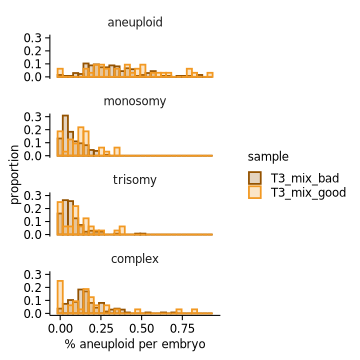

In [93]:
title <- "N3_hist_per_by_ploidy_norm"
w <- 3; h <- 3
options(repr.plot.width = w, repr.plot.height = h)

gghist <- ggplot(cell_karyo_long_df_sub, aes(x = per, fill = sample, colour = sample)) +
  geom_histogram(
    aes(y = after_stat(density * width)),
    bins = 30,
    position = "identity",
    alpha = 0.25
  ) +
  facet_wrap(~ploidy, ncol = 1) +
  #scale_x_continuous(limits = c(0, 1)) +
  labs(x = "% aneuploid per embryo", y = "proportion") +
  settheme +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample) 

# If you want your palette:
# gghist <- gghist + scale_fill_manual(values = custom_palette) + scale_colour_manual(values = custom_palette)

ggsave(plot = gghist, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)
gghist

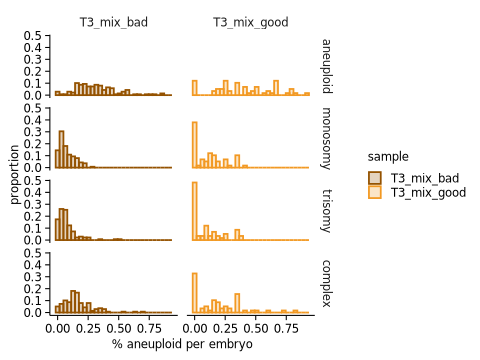

In [94]:
title <- "N4_hist_per_by_ploidy_norm"

cell_karyo_long_df_sub = cell_karyo_long_df%>%
subset(sample %in%c("T3_mix_good", "T3_mix_bad"))


w <- 4; h <- 3
options(repr.plot.width = w, repr.plot.height = h)

gghist <- ggplot(cell_karyo_long_df_sub, aes(x = per, fill = sample, colour = sample)) +
  geom_histogram(
    aes(y = after_stat(density * width)),
    bins = 30,
    position = "identity",
    alpha = 0.25
  ) +
  facet_grid(ploidy~sample) +
  #scale_y(limits = c(0, 1)) +
  labs(x = "% aneuploid per embryo", y = "proportion") +
  settheme +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample) 

# If you want your palette:
# gghist <- gghist + scale_fill_manual(values = custom_palette) + scale_colour_manual(values = custom_palette)

ggsave(plot = gghist, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)
gghist

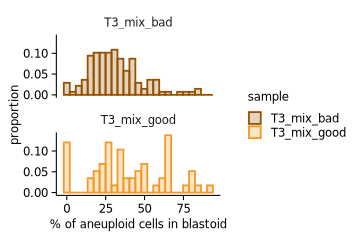

In [95]:
title <- "N4_hist_per_by_ploidy_norm"

cell_karyo_long_df_sub = cell_karyo_long_df%>%
subset(sample %in%c("T3_mix_good", "T3_mix_bad"))%>%
subset(ploidy  == "aneuploid")


w <- 3; h <- 2
options(repr.plot.width = w, repr.plot.height = h)

gghist <- ggplot(cell_karyo_long_df_sub, aes(x = per*100, fill = sample, colour = sample)) +
  geom_histogram(
    aes(y = after_stat(density * width)),
    bins = 25,
    position = "identity",
    alpha = 0.25
  ) +
  facet_wrap(~sample, ncol = 1) +
  #scale_y(limits = c(0, 1)) +
  labs(x = "% of aneuploid cells in blastoid", y = "proportion") +
  settheme +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample) 

# If you want your palette:
# gghist <- gghist + scale_fill_manual(values = custom_palette) + scale_colour_manual(values = custom_palette)

ggsave(plot = gghist, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)
gghist

### O) Scatter ratio of each chr

In [146]:
head(screen_counts)

chr,ploidy,sample,count
<int>,<fct>,<chr>,<int>
1,normal,T1_control,3965
1,normal,T1_rev,1998
1,normal,T2_control,6149
1,normal,T2_mix,6158
1,normal,T2_rev,2209
1,normal,T3_control,2271


In [96]:
df_prop <- screen_counts%>%
  group_by(chr, sample) %>%
  mutate(
    total_count = sum(count, na.rm = TRUE),
    prop = count / total_count
  ) %>%
  ungroup()%>%
  select(chr, sample,ploidy, prop)%>%
  pivot_wider(names_from = sample, values_from = prop)

df_prop$chr <- as.factor(df_prop$chr)
 

head(df_prop)

chr,ploidy,T1_control,T1_rev,T2_control,T2_mix,T2_rev,T3_control,T3_mix_bad,T3_mix_good,T3_naive_rev,T3_rev
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,normal,0.978529121,0.7168999,0.94440178,0.94811393,0.81573117,0.964331210,0.94906603,0.96287425,0.94140779,0.86196319
1,monosomy,0.012586377,0.1306064,0.02733835,0.02602002,0.08714919,0.026751592,0.02639010,0.02335329,0.02870625,0.08588957
1,trisomy,0.008884501,0.1524937,0.02825987,0.02586605,0.09711965,0.008917197,0.02454387,0.01377246,0.02988596,0.05214724
2,normal,0.958292201,0.6634374,0.94394102,0.94672825,0.79911374,0.969002123,0.94548219,0.95449102,0.92253244,0.88343558
2,monosomy,0.030355380,0.1772515,0.03225311,0.02863741,0.09268833,0.011464968,0.02410947,0.01616766,0.04482894,0.03680982
2,trisomy,0.011352419,0.1593111,0.02380587,0.02463433,0.10819793,0.019532909,0.03040834,0.02934132,0.03263862,0.07975460


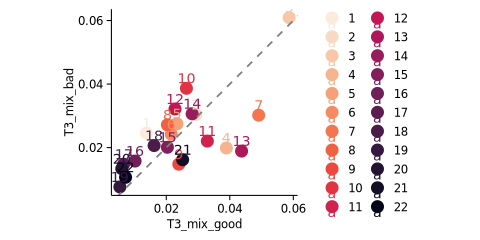

In [98]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T3_bad_T3_good_tri"

w <- 4
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_mix_bad, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
#scale_x_continuous(limits = c(0, 5.2)) +  # Set x-axis limits from 0 to 5
  #scale_y_continuous(limits = c(0, 5.2))  +
  coord_fixed(ratio = 1) +
geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

In [99]:
cor.test(
  df_prop_sub$T3_mix_good,
  df_prop_sub$T3_mix_bad,
  method = "pearson",
  use = "complete.obs"
)


	Pearson's product-moment correlation

data:  df_prop_sub$T3_mix_good and df_prop_sub$T3_mix_bad
t = 4.3043, df = 20, p-value = 0.0003454
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3841640 0.8628078
sample estimates:
      cor 
0.6934557 


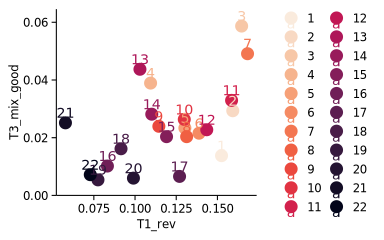

In [100]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T1rev_T3_good_tri"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T3_mix_good, color = chr)) +
  geom_point(size = 3) +
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
#scale_x_continuous(limits = c(0, 5.2)) +
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


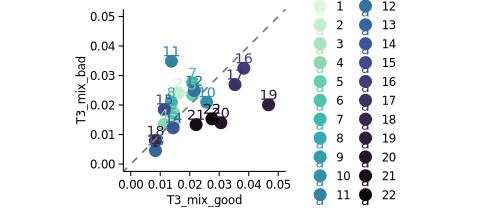

In [101]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "O2_scatter_T3_bad_T3_good_monosomy"

w <- 4
h <- 1.8
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_mix_bad, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
  scale_x_continuous(limits = c(0, 0.05)) +  # Set x-axis limits from 0 to 5
  scale_y_continuous(limits = c(0, 0.05)) +
  coord_fixed(ratio = 1) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

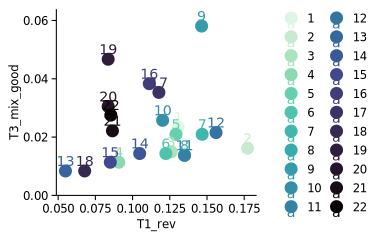

In [102]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "O1_scatter_T1rev_T3_good_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T3_mix_good, color = chr)) +
  geom_point(size = 3) +
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
#scale_x_continuous(limits = c(0, 5.2)) +
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

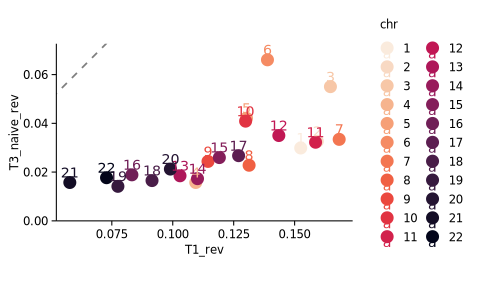

In [103]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T1_rev_T3_rev_tri"

w <- 4
h <- 2.5
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T3_naive_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  coord_fixed(ratio = 1) +
geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

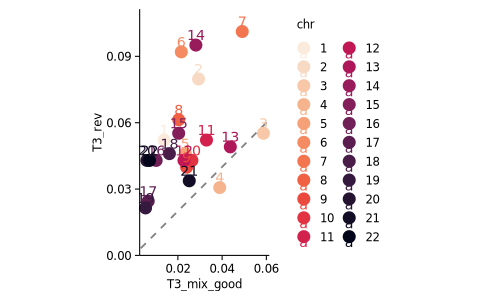

In [104]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T3_mosaic_good_T3_rev_tri"

w <- 4
h <- 2.5
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  coord_fixed(ratio = 1) +
geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

#### by cell type

In [105]:
screen_counts_2 <- merged_ploidydf %>% subset(sample == "T3_mix_good")%>% 
  group_by(chr, ploidy, celltype_coarse)%>%
  summarise(count= n(), .groups = "drop")%>%
  group_by(chr, ploidy) %>%
  mutate(
    EPI_TE_total = sum(count[celltype_coarse %in% c("EPI", "TE")], na.rm = TRUE),
    EPI_TE_total = if_else(celltype_coarse == "unspecified", count, EPI_TE_total)
  ) %>%
  ungroup()

In [106]:
head(screen_counts_2)

chr,ploidy,celltype_coarse,count,EPI_TE_total
<int>,<fct>,<chr>,<int>,<int>
1,normal,EPI,563,1528
1,normal,TE,965,1528
1,normal,unspecified,80,80
1,monosomy,EPI,8,32
1,monosomy,TE,24,32
1,monosomy,unspecified,7,7


In [107]:
df_prop_2 <- screen_counts_2%>%
  group_by(chr, celltype_coarse) %>%
  mutate(
    total_count = sum(count, na.rm = TRUE),
    prop = count / total_count
  ) %>%
  ungroup()%>%
  select(chr, celltype_coarse, ploidy, prop)%>%
  pivot_wider(names_from = celltype_coarse, values_from = prop)

df_prop_2$chr <- as.factor(df_prop_2$chr)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


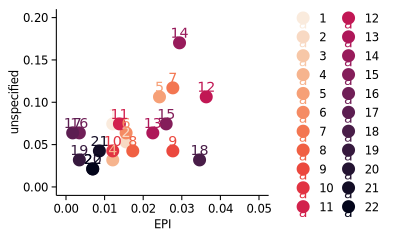

In [108]:
#plot
df_prop_sub = df_prop_2 %>% subset(ploidy == "trisomy")

title = "O1_scatter_EPI_unspecified_tri"

w <- 3.3
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# fit y ~ 0 + x  (through origin)
fit0 <- lm(unspecified ~ 0 + EPI, data = df_prop_sub)

slope0 <- coef(fit0)[["EPI"]]

ggscatter <- ggplot(df_prop_sub, aes(x = EPI, y = unspecified, color = chr)) +
  geom_point(size = 3) +
  #geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
  settheme +
  scale_color_viridis_d(option = "rocket", direction = -1) +
  scale_x_continuous(limits = c(0, 0.05)) +
  scale_y_continuous(limits = c(0, 0.2)) +
  #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
  geom_text(aes(label = chr), vjust = -0.5, size = 3)


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


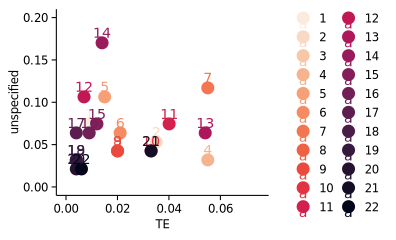

In [109]:
#plot
df_prop_sub = df_prop_2 %>% subset(ploidy == "trisomy")

title = "O1_scatter_TE_unspecified_tri"

w <- 3.3
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

fit0 <- lm(unspecified ~ 0 + TE, data = df_prop_sub)

slope0 <- coef(fit0)[["TE"]]

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = TE, y = unspecified, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme +
  #geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
  scale_color_viridis_d(option = "rocket", direction = -1)+
scale_x_continuous(limits = c(0, 0.075)) +  # Set x-axis limits from 0 to 5
  scale_y_continuous(limits = c(0, 0.2))  +
  #coord_fixed(ratio = 1) +
   #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


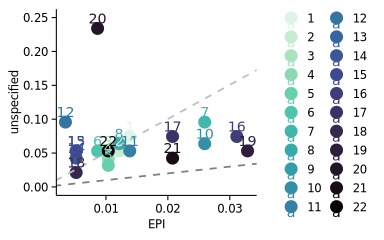

In [110]:
#plot
df_prop_sub = df_prop_2 %>% subset(ploidy == "monosomy")

title = "O1_scatter_EPI_unspecified_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# fit y ~ 0 + x  (through origin)
fit0 <- lm(unspecified ~ 0 + EPI, data = df_prop_sub)

slope0 <- coef(fit0)[["EPI"]]

ggscatter <- ggplot(df_prop_sub, aes(x = EPI, y = unspecified, color = chr)) +
  geom_point(size = 3) +
  geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
  settheme +
  scale_color_viridis_d(option = "mako", direction = -1)+
  #scale_x_continuous(limits = c(0, 0.05)) +
  scale_y_continuous(limits = c(0, 0.25)) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
  geom_text(aes(label = chr), vjust = -0.5, size = 3)


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


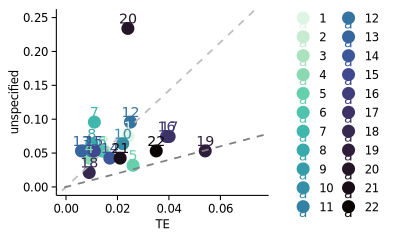

In [111]:
#plot
df_prop_sub = df_prop_2 %>% subset(ploidy == "monosomy")

title = "O1_scatter_TE_unspecified_mono"

w <- 3.3
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

fit0 <- lm(unspecified ~ 0 + TE, data = df_prop_sub)

slope0 <- coef(fit0)[["TE"]]

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = TE, y = unspecified, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme +
  geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
  scale_color_viridis_d(option = "mako", direction = -1)+
scale_x_continuous(limits = c(0, 0.075)) +  # Set x-axis limits from 0 to 5
  scale_y_continuous(limits = c(0, 0.25))  +
  #coord_fixed(ratio = 1) +
   geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

In [156]:
head(merged_cellkaryotype)

cell,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
AAACCTGAGACGCTTT-1_Embryo-Imp15265942,13+,trisomy,1,0,45,1,26051,Embryo-Imp15265942,0.24050633,False,0.26363636,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified
AAACCTGAGATCGGGT-1_Embryo-Imp15265944,16-,monosomy,0,1,43,1,38163,Embryo-Imp15265944,0.12479741,False,0.13000000,0.6744908,1,0.8897991,6079,46417,2452,5.282547,10633,22.90755,high,-0.06009019,0.30989354,G2M,4,-0.0272863224,,TE,T3_control,day6,Control,Blastoid_Gd,6079,0.3099473,6,6,6,5,TE,5,TE_2,TE
AAACCTGAGCCGATTT-1_Embryo-Imp15265941,"3+, 4+, 15-, 16-, 17-",complex,2,3,43,5,22413,Embryo-Imp15265941,0.17590361,False,0.12959381,-1.0563108,1,0.9994763,9876,67268,1430,2.125825,13924,20.69929,high,0.10803721,0.33061543,G2M,7,-0.0504074723,,TE,T2_rev,day4,Reversine,Intermediate,9876,0.2868795,4,12,5,7,unspecified,3,unspecified_1,unspecified
AAACCTGAGCGATCCC-1_Embryo-Imp15265941,15-,monosomy,0,1,43,1,22414,Embryo-Imp15265941,0.10769231,False,0.09234592,-1.7547179,1,0.9994763,7782,58289,1207,2.070717,16057,27.54722,high,0.17155702,0.11663077,S,2,-0.0089781450,,TE,T2_rev,day4,Reversine,Intermediate,7782,0.2824723,1,1,0,6,unspecified,4,unspecified_1,unspecified
AAACCTGAGCGTTGCC-1_Embryo-Imp15265940,"1+, 11+, 12+, 14+, 17+, 20+",complex,6,0,50,6,14190,Embryo-Imp15265940,0.04516129,False,0.05639396,-2.0410444,1,0.9949815,7293,40370,1063,2.633143,8254,20.44588,high,0.09479948,0.79549555,G2M,12,0.0499759532,,TE,T2_control,day4,Control,Intermediate,7293,0.3496189,5,9,7,14,unspecified,3,unspecified_1,unspecified
AAACCTGAGCTATGCT-1_Embryo-Imp15265941,"9-, 16-, 21+",complex,1,2,43,3,22415,Embryo-Imp15265941,0.25239617,False,0.18091663,-0.0939953,1,0.9994763,7551,52236,706,1.351558,13965,26.73444,high,0.28461735,-0.01922053,S,1,-0.0352441995,,TE,T2_rev,day4,Reversine,Intermediate,7551,0.2738227,7,7,8,9,unspecified,0,unspecified_1,unspecified


### P) Scatter per type aneuploid against aneuploidy

In [154]:
reformatted_cell_karyo = cell_karyo_long_df_sub %>%
  group_by(sample, filtered_feature_call, dataset, timepoint, Condition) %>%
  mutate(per_aneuploid = per[ploidy == "aneuploid"][1]) %>%
  filter(per_aneuploid != 0)%>%
  filter(ploidy != "aneuploid")%>%
  #filter(filtered_feature_call != "fail")%>%
  mutate(
    per_in_aneuploid = 
      per / sum(per))%>%
  ungroup()

In [155]:
head(reformatted_cell_karyo)

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,ploidy,per,per_aneuploid,per_in_aneuploid
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<fct>,<dbl>,<dbl>,<dbl>


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


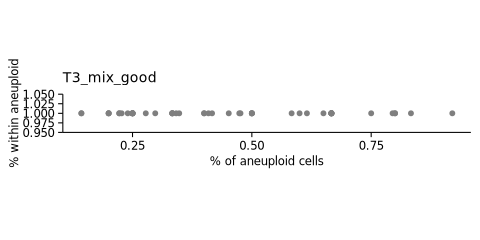

In [153]:
#plot
reformatted_cell_karyop_sub = reformatted_cell_karyo %>% subset(sample == "T3_mix_good")

title = "P1_scatter_T3good"

w <- 4
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(reformatted_cell_karyop_sub, aes(x = per_aneuploid, y = per_in_aneuploid , color = ploidy)) +
      geom_point(size = 1) +
    labs(x = "% of aneuploid cells", 
     y = "% within aneuploid", 
    title = "T3_mix_good") +
    settheme+
    scale_fill_manual(values=color_ploidy)+
    scale_color_manual(values=color_ploidy)+
    coord_fixed(ratio = 0.8) 

ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


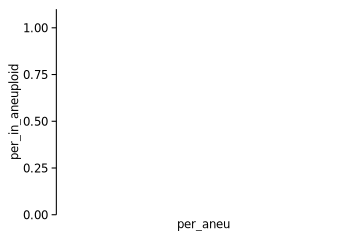

In [114]:
# 1) Bin x-values (per_aneuploid_blastoid) into two groups
blastoid_celltype_binned <- reformatted_cell_karyop_sub %>%
  mutate(
    per_aneu = cut(
      per_in_aneuploid,
      breaks = c(-Inf, 0.5, Inf),                 # change 0.5 if you prefer another split
      labels = c("≤50%", ">50%")
    )
  )

# 2) Bar chart: mean prop cell type per bin, per celltype
w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)


title = "P2_bar_T3good"

gg_bar <- ggplot(
  blastoid_celltype_binned,
  aes(
    x    = per_aneu,
    y    = per_in_aneuploid,
    fill = ploidy
  )
) +
  geom_bar(
    stat     = "summary",
    fun      = "mean",
    position = position_dodge(width = 0.9),
    alpha    = 0.7
  ) +
  # dots: one per blastoid, jittered & dodged
  geom_point(
    aes(color = ploidy),
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width  = 0.9
    ),
    size  = 1,
    alpha = 0.8
  ) +
  # optional error bars: SE of the mean per bin & celltype
  stat_summary(
    fun.data = "mean_se",
    geom     = "errorbar",
    position = position_dodge(width = 0.9),
    width    = 0.2,
    color    = "grey20"
  ) +settheme+
    scale_y_continuous(
    expand = c(0, 0),limits = c(0, 1.1))+
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )+
    scale_fill_manual(values=color_ploidy)+
    scale_color_manual(values=color_ploidy)


ggsave(
  plot     = gg_bar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_bar


### Q) plot heatmap for each blastoid

In [115]:
joint_meta = cell_chr_df %>%
    mutate(ploidy_col = case_when(
      ploidy == "trisomy" ~ 3,
      ploidy == "monosomy" ~ 1,
      TRUE ~ 2))

In [157]:
head(joint_meta)

,cell,chr,z,score,p,p.adj,monosomy,ploidy,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,X.y,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call,ploidy_col
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,13,-1.05816939,0.8513222,0.2899874,0.8904334,TRUE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,2
2,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,21,0.52101068,1.0576815,0.6023635,1.0000000,FALSE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,2
3,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,9,-0.19081584,1.0215320,0.8486713,1.0000000,TRUE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,2
4,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,7,0.01321689,1.0009554,0.9894548,1.0000000,FALSE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,2
5,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,5,-0.41042483,0.9691512,0.6814975,1.0000000,TRUE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,2
6,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,3,0.15123917,0.9990446,0.8797881,1.0000000,FALSE,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,2


In [116]:
ploidy_heat_df = dcast(joint_meta, cell+filtered_feature_call + sample + celltype_coarse ~ chr, value.var="ploidy_col")

In [117]:
#add color
ploidy_heat_df  = ploidy_heat_df %>%
    mutate(plot_var = case_when(
   celltype_coarse == "EPI"~"#D0555E", 
   celltype_coarse == "TE"~"#61A59B",
   celltype_coarse == "unspecified"~"#676767"
  ))

In [118]:
ploidy_heat_df = ploidy_heat_df[order(ploidy_heat_df$celltype_coarse, decreasing = TRUE),]

In [119]:
plot_heatmaps_for_condition <- function(ploidy_heat_df,
                                        condition
) {
    cols = 4
    min_n = 5
    png_w = 500
    png_h = 400

  embryo_analyse <- ploidy_heat_df %>%
    filter(sample == condition,
           filtered_feature_call != "fail",
           filtered_feature_call != "") %>%
    count(filtered_feature_call, name = "n") %>%
    filter(n > min_n)

  embryos <- embryo_analyse$filtered_feature_call

  if (length(embryos) == 0) {
    message(sprintf("No embryos found for condition %s (n>%d). Skipping.", condition, min_n))
    return(invisible(NULL))
  }

  plot_list <- vector("list", length(embryos))
  names(plot_list) <- embryos

  for (embryo_i in embryos) {

    cnv_embryo <- ploidy_heat_df %>%
      filter(sample == condition, filtered_feature_call == embryo_i)

    if (nrow(cnv_embryo) == 0) next

    rownames(cnv_embryo) <- cnv_embryo$cell
    plot_var_list <- cnv_embryo$plot_var

    # keep chr1..chr22 columns (as characters "1":"22")
    cnv_mat <- cnv_embryo[, as.character(1:22)]
    cnv_mat <- as.matrix(cnv_mat)

    my_palette <- if (1 %in% cnv_mat) c("#109E9D", "grey90", "#F26B3B") else c("grey90", "#F26B3B")

    tmp <- tempfile(fileext = ".png")
    png(tmp, width = png_w, height = png_h)

    heatmap.2(
      x = cnv_mat,
      Colv = FALSE, Rowv = TRUE,
      dendrogram = "none",
      col = my_palette,
      RowSideColors = plot_var_list,
      trace = "none",
      main = embryo_i,
      sepcolor = "WHITE",
      colsep = 1:ncol(cnv_mat),
      rowsep = 1:nrow(cnv_mat),
      sepwidth = c(0.05, 0.05),
      cexRow = 1, cexCol = 1,
      margins = c(1, 1),
      key = FALSE,
      lwid = c(0.1, 4),
      lhei = c(0.8, 4)
    )

    dev.off()

    img <- png::readPNG(tmp)
    plot_list[[embryo_i]] <- grid::rasterGrob(img, interpolate = TRUE)

    unlink(tmp)
  }

  # drop any NULL grobs (in case of missing embryos)
  plot_list <- plot_list[!vapply(plot_list, is.null, logical(1))]
  n <- length(plot_list)
  if (n == 0) return(invisible(NULL))

  rows <- ceiling(n / cols)

  pdf(
    file = sprintf("%s/Q_heatmap_embryos_%s.pdf", outdir, condition),
    width = 5 * cols,
    height = 4 * rows
  )
  gridExtra::grid.arrange(grobs = plot_list, ncol = cols)
  dev.off()

  invisible(plot_list)
}


In [120]:
plot_heatmaps_for_condition(ploidy_heat_df, "T3_rev")
plot_heatmaps_for_condition(ploidy_heat_df, "T3_mix_good")
plot_heatmaps_for_condition(ploidy_heat_df, "T3_mix_bad")

### R) bar cell type, chr

In [121]:
head(merged_ploidydf,3)

,chr,cell,z,score,p,p.adj,monosomy,ploidy,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,1,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.007713042,0.9976855,0.9938460,1.0000000,TRUE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
2,10,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,-0.722146042,0.9367999,0.4702108,0.9910863,TRUE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
3,11,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1.896537105,1.1236714,0.0578994,0.3990391,FALSE,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified


Warning message:
“Removed 66 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 66 rows containing missing values or values outside the scale range
(`geom_bar()`).”


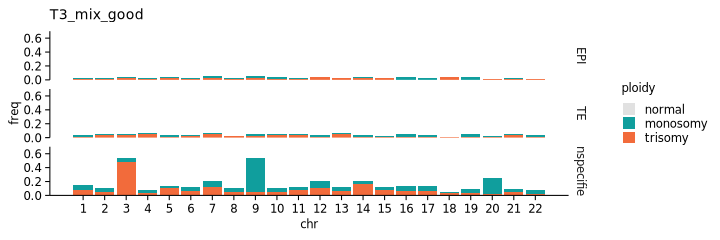

In [122]:
#plot
merged_ploidydf_sub = merged_ploidydf %>% filter(sample == "T3_mix_good") 

title = "R_freq_perchr_celltype"

w <- 6
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
merged_ploidydf_sub$ploidy <- factor(merged_ploidydf_sub$ploidy, levels = order)

gg_bar = ggplot(merged_ploidydf_sub, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill')+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.7), breaks = seq(0, 0.7, by = 0.2))+
  scale_x_continuous(breaks = seq(1,22, by = 1))+
  labs(title = "T3_mix_good", y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))+
  facet_grid(celltype_coarse ~.)

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

Warning message:
“Removed 66 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 66 rows containing missing values or values outside the scale range
(`geom_bar()`).”


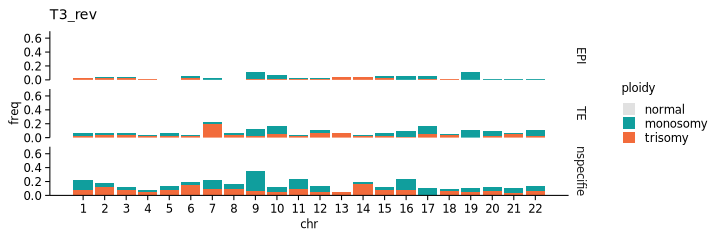

In [123]:
#plot
merged_ploidydf_sub = merged_ploidydf %>% filter(sample == "T3_rev") 

title = "R2_freq_perchr_celltype_rev"

w <- 6
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
merged_ploidydf_sub$ploidy <- factor(merged_ploidydf_sub$ploidy, levels = order)

gg_bar = ggplot(merged_ploidydf_sub, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill')+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.7), breaks = seq(0, 0.7, by = 0.2))+
  scale_x_continuous(breaks = seq(1,22, by = 1))+
  labs(title = "T3_rev", y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))+
  facet_grid(celltype_coarse ~.)

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

### S) % each cell type per condition

In [124]:
head(cell_karyo_df, 3)

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,25866,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.29044464,0.15769816,S,6,-0.0409680033,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,1,13+,trisomy,1,0,45,1,Embryo-Imp15265942,0.2405063,False,0.2636364,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified,AAACCTGAGACGCTTT,1,pooled_BC_57,284,Embryo-Imp15265942,pooled_BC_57
3,AAACCTGAGAGTCGGT-1_Embryo-Imp15265946,25867,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.2409639,True,0.2263610,1.0691784,1,0.9224943,5816,25038,529,2.112788,6271,25.04593,high,0.02287884,0.20074458,G2M,6,-0.0466536458,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5816,0.3535609,1,1,0,6,unspecified,2,unspecified_1,unspecified,AAACCTGAGAGTCGGT,1,pooled_BC_155,509,Embryo-Imp15265946,pooled_BC_155


In [125]:
#summarise
cell_karyo_df_summary <- cell_karyo_df%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )%>%
  mutate(celltype_coarse = factor(celltype_coarse , levels = c("EPI", "TE", "unspecified"))) %>%
  group_by(filtered_feature_call, sample, celltype_coarse,.drop = FALSE) %>%
  summarise(count = n()) %>%
  mutate(sum = sum(count)) %>%
  #filter(sum(count) >= 10) %>%
  mutate(prop = count / sum(count)) %>%
  ungroup()

`summarise()` has grouped output by 'filtered_feature_call', 'sample'. You can
override using the `.groups` argument.


In [126]:
head(cell_karyo_df_summary)

filtered_feature_call,sample,celltype_coarse,count,sum,prop
<chr>,<chr>,<fct>,<int>,<int>,<dbl>
pooled_BC_1,T2_control,EPI,0,8,0
pooled_BC_1,T2_control,TE,0,8,0
pooled_BC_1,T2_control,unspecified,8,8,1
pooled_BC_1,T2_mix,EPI,0,18,0
pooled_BC_1,T2_mix,TE,0,18,0
pooled_BC_1,T2_mix,unspecified,18,18,1


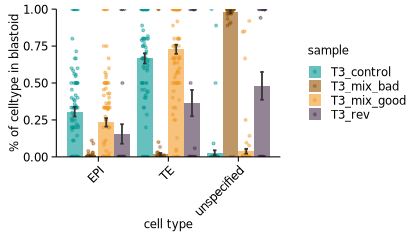

In [127]:
cell_karyo_df_summary_sub <- 
  cell_karyo_df_summary %>% 
  filter(sample %in% c("T3_rev", "T3_mix_good", "T3_mix_bad", "T3_control"))

title <- "S_per_celltype_condition"

w <- 3.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# define a common dodge for bars + errorbars
pos_dodge <- position_dodge(width = 0.9)

pos_dodge <- position_dodge(width = 0.9)

ggbar <- ggplot(
  cell_karyo_df_summary_sub,
  aes(x = celltype_coarse, y = prop, fill = sample)
) +
  geom_bar(stat = "summary", fun = "mean", position = pos_dodge, alpha = 0.6) +
  geom_point(
    aes(color = sample),
    size = 0.5, alpha = 0.4,
    position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.9)
  ) +
  stat_summary(
    fun.data  = "mean_se",
    geom      = "errorbar",
    width     = 0.2,
    color     = "grey20",
    position  = pos_dodge
  ) +
  labs(x = "cell type", y = "% of celltype in blastoid") +
  settheme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
    # , legend.position = "none"
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample)


ggsave(
  plot     = ggbar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

ggbar


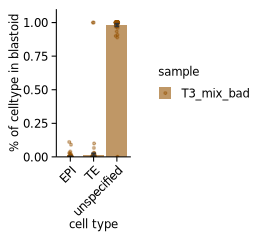

In [128]:
cell_karyo_df_summary_sub <- 
  cell_karyo_df_summary %>% 
  filter(sample %in% c("T3_mix_bad"))

title <- "S_per_celltype_condition"

w <- 2.2
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# define a common dodge for bars + errorbars
pos_dodge <- position_dodge(width = 0.9)

pos_dodge <- position_dodge(width = 0.9)

ggbar <- ggplot(
  cell_karyo_df_summary_sub,
  aes(x = celltype_coarse, y = prop, fill = sample)
) +
  geom_bar(stat = "summary", fun = "mean", position = pos_dodge, alpha = 0.6) +
  geom_point(
    aes(color = sample),
    size = 0.5, alpha = 0.4,
    position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.9)
  ) +
  stat_summary(
    fun.data  = "mean_se",
    geom      = "errorbar",
    width     = 0.2,
    color     = "grey20",
    position  = pos_dodge
  ) +
  labs(x = "cell type", y = "% of celltype in blastoid") +
  settheme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
    # , legend.position = "none"
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1.1)) +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample)


ggsave(
  plot     = ggbar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

ggbar

### T) % celltype against %ploidy 

In [129]:
# 0) define what counts as aneuploid
df2 <- cell_karyo_df%>%
  mutate(
    is_aneuploid = ploidy != "diploid"
  )%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )

# 1) per-blastoid summary: overall % aneuploid in that blastoid (y-axis)
blastoid_summary <- df2 %>%
  group_by(filtered_feature_call, sample) %>%   # keep sample if you want it for colouring
  summarise(
    n_cells_blastoid  = n(),
    n_aneuploid_blastoid = sum(is_aneuploid),
    per_aneuploid_blastoid = n_aneuploid_blastoid / n_cells_blastoid,
    .groups = "drop"
  )

# 2) per-blastoid × celltype: fraction of blastoid that is this cell type (x-axis)
blastoid_celltype <- df2 %>%
  group_by(filtered_feature_call, sample, celltype_coarse) %>%
  summarise(
    n_cells_celltype = n(),
    .groups = "drop"
  ) %>%
  left_join(blastoid_summary, by = c("filtered_feature_call", "sample")) %>%
  mutate(
    per_celltype = n_cells_celltype / n_cells_blastoid
  )

# filter small celltype counts per blastoid
#blastoid_celltype <- blastoid_celltype %>% filter(n_cells_celltype >= 5)   # tweak threshold


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


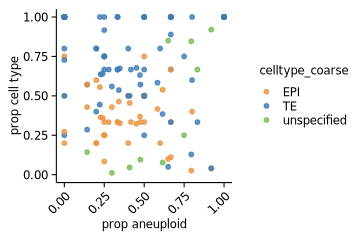

In [130]:
## 3) Plot: x = % of blastoid that is this cell type, y = % aneuploid in blastoid
w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

title = "T1_peraneu_per_celltype"

blastoid_celltype_sub = blastoid_celltype %>% 
  filter(sample %in% c( "T3_mix_good"))


gg_scatter <- ggplot(
  blastoid_celltype_sub ,
  aes(
    x = per_aneuploid_blastoid,
    y = per_celltype,
    color = celltype_coarse    # or sample, depending on what you want to highlight
  )
) +
  geom_point(size = 1, alpha = 0.8) +
  # optional smoothing / trend per cell type
  # geom_smooth(method = "lm", se = FALSE, size = 0.3) +
  scale_x_continuous(
    "prop aneuploid",
    limits = c(0, 1)
  ) +
  scale_y_continuous(
    "prop cell type",
    limits = c(0, 1)
  ) +
  settheme+
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )+
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)

ggsave(
  plot     = gg_scatter,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_scatter

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≤50%' in 'mbcsToSbcs': <= substituted for ≤ (U+2264)”


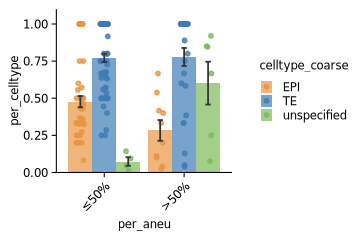

In [131]:
# 1) Bin x-values (per_aneuploid_blastoid) into two groups
blastoid_celltype_binned <- blastoid_celltype_sub  %>%
  mutate(
    per_aneu = cut(
      per_aneuploid_blastoid,
      breaks = c(-Inf, 0.5, Inf),                 # change 0.5 if you prefer another split
      labels = c("≤50%", ">50%")
    )
  )

# 2) Bar chart: mean prop cell type per bin, per celltype
w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)


title = "T2_bar_peraneu_per_celltype"

gg_bar <- ggplot(
  blastoid_celltype_binned,
  aes(
    x    = per_aneu,
    y    = per_celltype,
    fill = celltype_coarse
  )
) +
  geom_bar(
    stat     = "summary",
    fun      = "mean",
    position = position_dodge(width = 0.9),
    alpha    = 0.7
  ) +
  # dots: one per blastoid, jittered & dodged
  geom_point(
    aes(color = celltype_coarse),
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width  = 0.9
    ),
    size  = 1,
    alpha = 0.8
  ) +
  # optional error bars: SE of the mean per bin & celltype
  stat_summary(
    fun.data = "mean_se",
    geom     = "errorbar",
    position = position_dodge(width = 0.9),
    width    = 0.2,
    color    = "grey20"
  ) +settheme+
    scale_y_continuous(
    expand = c(0, 0),limits = c(0, 1.1))+
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )+
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)


ggsave(
  plot     = gg_bar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_bar


In [132]:
# 0) define aneuploid vs normal
df2 <- cell_karyo_df%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )%>%
  mutate(
    # adjust "normal" label if needed
    is_aneuploid = ploidy != "diploid"
    # e.g. is_aneuploid = ploidy %in% c("monosomy", "trisomy", "loh")
  )

# 1) per-blastoid summary: overall % aneuploid in that blastoid (x-axis)
blastoid_summary <- df2 %>%
  group_by(filtered_feature_call, sample) %>%
  summarise(
    n_cells_blastoid      = n(),
    n_aneuploid_blastoid  = sum(is_aneuploid),
    per_aneuploid_blastoid = n_aneuploid_blastoid / n_cells_blastoid,
    .groups = "drop"
  )

# 2) per-blastoid × celltype: % aneuploid within that celltype (y-axis)
blastoid_celltype <- df2 %>%
  group_by(filtered_feature_call, sample, celltype_coarse) %>%  # rename for convenience
  summarise(
    n_cells_ct      = n(),
    n_aneuploid_ct  = sum(is_aneuploid),
    per_aneuploid_ct = n_aneuploid_ct / n_cells_ct,   # y-axis
    .groups = "drop"
  ) %>%
  left_join(blastoid_summary,
            by = c("filtered_feature_call", "sample"))

# Optional: filter out very small celltype groups per blastoid
#blastoid_celltype <- blastoid_celltype %>%filter(n_cells_ct >= 3)  # tweak threshold if you like


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


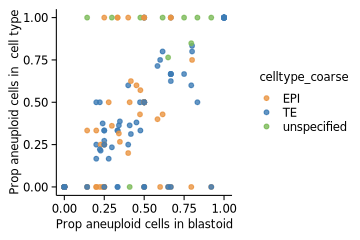

In [133]:
# 3) Plot: x = overall % aneuploid in blastoid, y = % aneuploid in that celltype in that blastoid
w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)


title <- "T3_perAneuCT_vs_globalAneu"

blastoid_celltype_sub = blastoid_celltype %>% 
  filter(sample %in% c( "T3_mix_good"))

gg_scatter <- ggplot(
  blastoid_celltype_sub,
  aes(
    x = per_aneuploid_blastoid,   # overall aneuploid fraction (blastoid)
    y = per_aneuploid_ct,         # celltype-specific aneuploid fraction
    color = celltype_coarse       # or sample, depending on what you want
  )
) +
  geom_point(size = 1, alpha = 0.8) +
  # optional: trend lines per celltype
  # geom_smooth(method = "lm", se = FALSE, size = 0.3) +
  scale_x_continuous(
    "Prop aneuploid cells in blastoid",
    limits = c(0, 1)
  ) +
  scale_y_continuous(
    "Prop aneuploid cells in  cell type",
    limits = c(0, 1)
  ) +
  settheme+
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)


ggsave(
  plot     = gg_scatter,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_scatter

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≤50%' in 'mbcsToSbcs': <= substituted for ≤ (U+2264)”


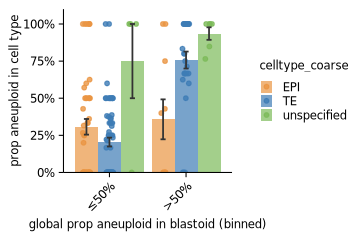

In [134]:
# 1) Bin x-values (overall aneuploidy per blastoid) into two groups
blastoid_celltype_binned <- blastoid_celltype_sub %>%
  mutate(
    per_aneu_bin = cut(
      per_aneuploid_blastoid,
      breaks = c(-Inf, 0.5, Inf),   # change 0.5 if you prefer another split
      labels = c("≤50%", ">50%")
    )
  )

w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

title <- "T4_bar_perAneuCT_vs_globalAneu_bin"

dodge_width <- 0.9
pos_dodge   <- position_dodge(width = dodge_width)

gg_bar <- ggplot(
  blastoid_celltype_binned,
  aes(
    x    = per_aneu_bin,
    y    = per_aneuploid_ct,   # <- y = % aneuploid within this celltype
    fill = celltype_coarse
  )
) +
  # bars: mean per bin × celltype
  geom_bar(
    stat     = "summary",
    fun      = "mean",
    position = pos_dodge,
    alpha    = 0.7
  ) +
  # dots: one per blastoid (per celltype), jittered & dodged
  geom_point(
    aes(color = celltype_coarse),
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width  = dodge_width
    ),
    size  = 1,
    alpha = 0.8
  ) +
  # error bars: SE of mean per bin × celltype
  stat_summary(
    fun.data = "mean_se",
    geom     = "errorbar",
    position = pos_dodge,
    width    = 0.2,
    color    = "grey20"
  ) +
  settheme +
  scale_y_continuous(
    "prop aneuploid in cell type",
    expand = c(0, 0),
    limits = c(0, 1.1),
    labels = percent_format(accuracy = 1)
  ) +
  scale_x_discrete("global prop aneuploid in blastoid (binned)") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)

ggsave(
  plot     = gg_bar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_bar


In [135]:
head(blastoid_celltype_binned)

filtered_feature_call,sample,celltype_coarse,n_cells_ct,n_aneuploid_ct,per_aneuploid_ct,n_cells_blastoid,n_aneuploid_blastoid,per_aneuploid_blastoid,per_aneu_bin
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<fct>
pooled_BC_1,T3_mix_good,TE,1,0,0,1,0,0.00,≤50%
pooled_BC_100,T3_mix_good,EPI,1,0,0,2,1,0.50,≤50%
pooled_BC_100,T3_mix_good,TE,1,1,1,2,1,0.50,≤50%
pooled_BC_101,T3_mix_good,TE,1,0,0,1,0,0.00,≤50%
pooled_BC_102,T3_mix_good,TE,2,2,1,2,2,1.00,>50%
pooled_BC_104,T3_mix_good,EPI,1,0,0,12,3,0.25,≤50%


In [136]:
blastoid_celltype_binned %>%
  group_by(celltype_coarse) %>%
  pairwise_wilcox_test(
    per_aneuploid_ct ~ per_aneu_bin,
    p.adjust.method = "none"
  ) 

,celltype_coarse,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,EPI,per_aneuploid_ct,≤50%,>50%,44,10,213.5,8.88e-01,8.88e-01,ns
2,TE,per_aneuploid_ct,≤50%,>50%,67,29,197.0,1.96e-10,1.96e-10,****
3,unspecified,per_aneuploid_ct,≤50%,>50%,4,6,12.0,1.00e+00,1.00e+00,ns


### U) Cell type, ploidy , per structure

In [137]:
library(dplyr)
library(ggplot2)

plot_celltype_ratio_per_structure <- function(
  cell_karyo_df,
  sample_name        = "T3_mix_bad",
  plot_var       = celltype_coarse,    # bare column name
  priority_celltypes = c("EPI", "TE"),     # used for ordering structures
  title              = NULL,
   w = 20,
   h = 2.5
) {
  if (is.null(title)) {
    title <- sprintf("celltype_ratio_%s", sample_name)
  }
  


  # Compute ratios
  df_ratio_celltype <- cell_karyo_df %>%
    filter(!is.na({{ plot_var }})) %>%
    filter(sample == sample_name) %>%
    filter(filtered_feature_call != "fail") %>%
    group_by(filtered_feature_call, {{ plot_var }}) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(filtered_feature_call) %>%
    mutate(sum = sum(count)) %>%
    filter(sum >= 5) %>%
    mutate(ratio = count / sum) %>%
    ungroup()

  # Optional: order structures so those enriched in priority celltypes come first
  if (length(priority_celltypes) > 0) {
    df_ratio_celltype <- df_ratio_celltype %>%
      mutate(
        .priority = {{ plot_var }} %in% priority_celltypes
      ) %>%
      arrange(desc(.priority), desc(ratio))
  }

  # Order on x-axis
  order <- unique(df_ratio_celltype$filtered_feature_call)
  sample_order <- factor(order, levels = order)

  df_ratio_celltype <- df_ratio_celltype %>%
    mutate(filtered_feature_call = factor(filtered_feature_call, levels = order))

  # Plot
  options(repr.plot.width = w, repr.plot.height = h)

  bar_ratio <- ggplot(
    df_ratio_celltype,
    aes(x = filtered_feature_call, y = ratio, fill = {{ plot_var }})
  ) +
    geom_bar(stat = "identity", position = "stack") +
    labs(
      x    = "Structure",
      y    = "Ratio",
      title = sample_name, 
      fill = deparse(substitute(plot_var))
    ) +
    settheme +
    scale_fill_manual(values = color_celltype) +
    scale_color_manual(values = color_celltype) +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
    ) +
    scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
    scale_x_discrete(limits = sample_order)

  ggsave(
    plot     = bar_ratio,
    filename = sprintf("%s/%s.pdf", outdir, title),
    width    = w,
    height   = h
  )

  bar_ratio
}


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


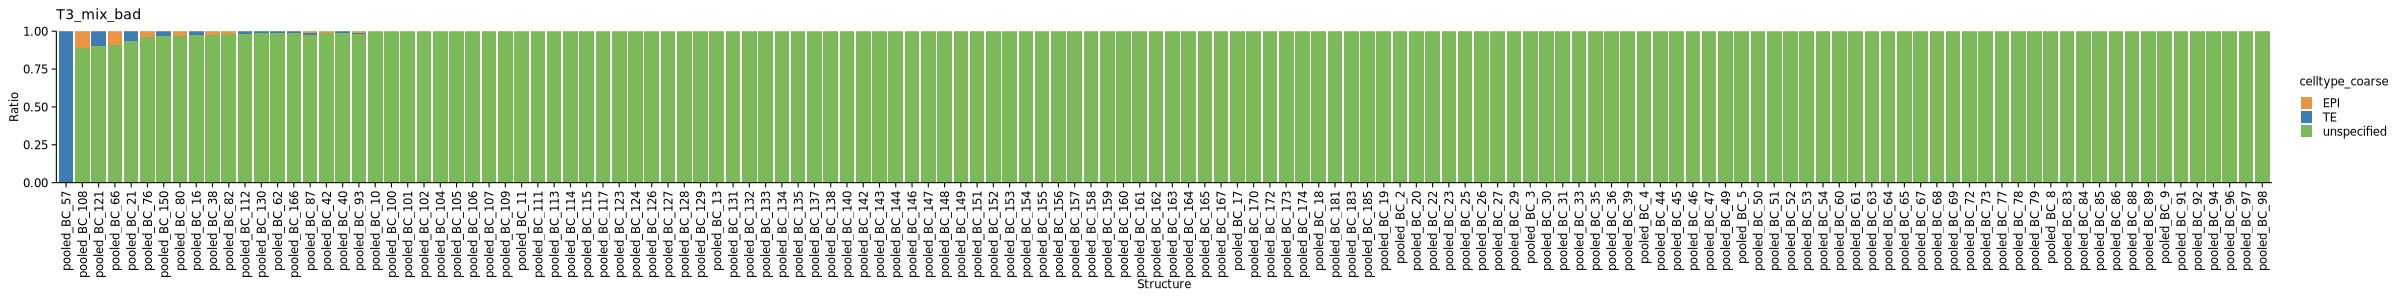

In [138]:
plot_celltype_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_mix_bad",
  plot_var = celltype_coarse,
  title        = "U1_celltype_ratio_structure"
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


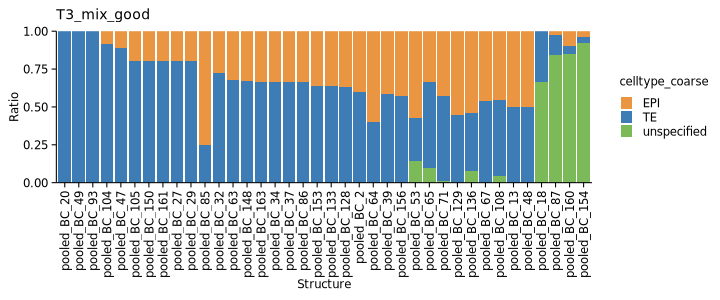

In [139]:
plot_celltype_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_mix_good",
  plot_var = celltype_coarse,
  title        = "U2_celltype_ratio_structure",
   w = 6
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


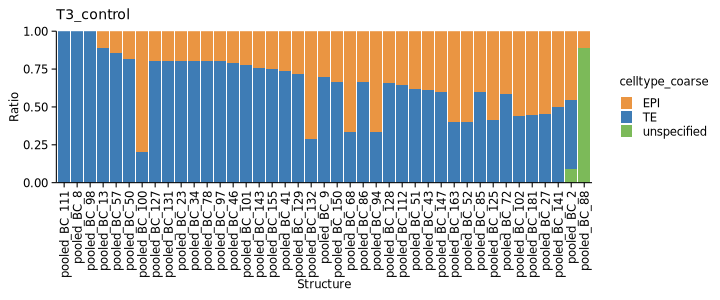

In [140]:
plot_celltype_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_control",
  plot_var = celltype_coarse,
  title        = "U3_celltype_ratio_structure",
    w = 6
)

In [141]:
plot_ploidy_ratio_per_structure <- function(
  cell_karyo_df,
  sample_name        = "T3_mix_bad",
  plot_var           = ploidy,          # bare column name, usually 'ploidy'
  ordering_var       = celltype_coarse, # bare column name used for ordering (cell type)
  priority_celltypes = c("EPI", "TE"),  # used for ordering structures
  title              = NULL,
  w                  = 20,
  h                  = 2.5
) {
  if (is.null(title)) {
    title <- sprintf("ploidy_ratio_%s", sample_name)
  }

  df_order <- cell_karyo_df %>%
    filter(!is.na({{ ordering_var }})) %>%
    filter(sample == sample_name) %>%
    filter(filtered_feature_call != "fail") %>%
    group_by(filtered_feature_call, {{ ordering_var }}) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(filtered_feature_call) %>%
    mutate(sum = sum(count)) %>%
    filter(sum >= 5) %>%
    mutate(ratio = count / sum) %>%
    ungroup()

  if (length(priority_celltypes) > 0) {
    df_order <- df_order %>%
      mutate(
        .priority = {{ ordering_var }} %in% priority_celltypes
      ) %>%
      arrange(desc(.priority), desc(ratio))
  }

  order_struct <- unique(df_order$filtered_feature_call)
  sample_order <- factor(order_struct, levels = order_struct)

  df_ploidy <- cell_karyo_df %>%
    filter(!is.na({{ plot_var }})) %>%
    filter(sample == sample_name) %>%
    filter(filtered_feature_call != "fail") %>%
    group_by(filtered_feature_call, {{ plot_var }}) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(filtered_feature_call) %>%
    mutate(
      sum   = sum(count),
      ratio = count / sum
    ) %>%
    ungroup() %>%
    filter(sum >= 5) %>%
    mutate(
      filtered_feature_call = factor(filtered_feature_call,
                                     levels = order_struct)
    )

  if (as.character(substitute(plot_var)) == "ploidy") {
    ploidy_order <- c("diploid", "complex", "monosomy", "trisomy")
    df_ploidy <- df_ploidy %>%
      mutate(ploidy = factor(ploidy, levels = ploidy_order))
  }

  options(repr.plot.width = w, repr.plot.height = h)

  bar_ratio <- ggplot(
    df_ploidy,
    aes(x = filtered_feature_call, y = ratio, fill = {{ plot_var }})
  ) +
    geom_bar(stat = "identity", position = "stack") +
    labs(
      x     = "Structure",
      y     = "Ratio",
      title =  sample_name,
      fill  = deparse(substitute(plot_var))
    ) +
    settheme +
    scale_fill_manual(values = color_ploidy_2) +
    scale_color_manual(values = color_ploidy_2) +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
    ) +
    scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
    scale_x_discrete(limits = sample_order)

  ggsave(
    plot     = bar_ratio,
    filename = sprintf("%s/%s.pdf", outdir, title),
    width    = w,
    height   = h
  )

  bar_ratio
}


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


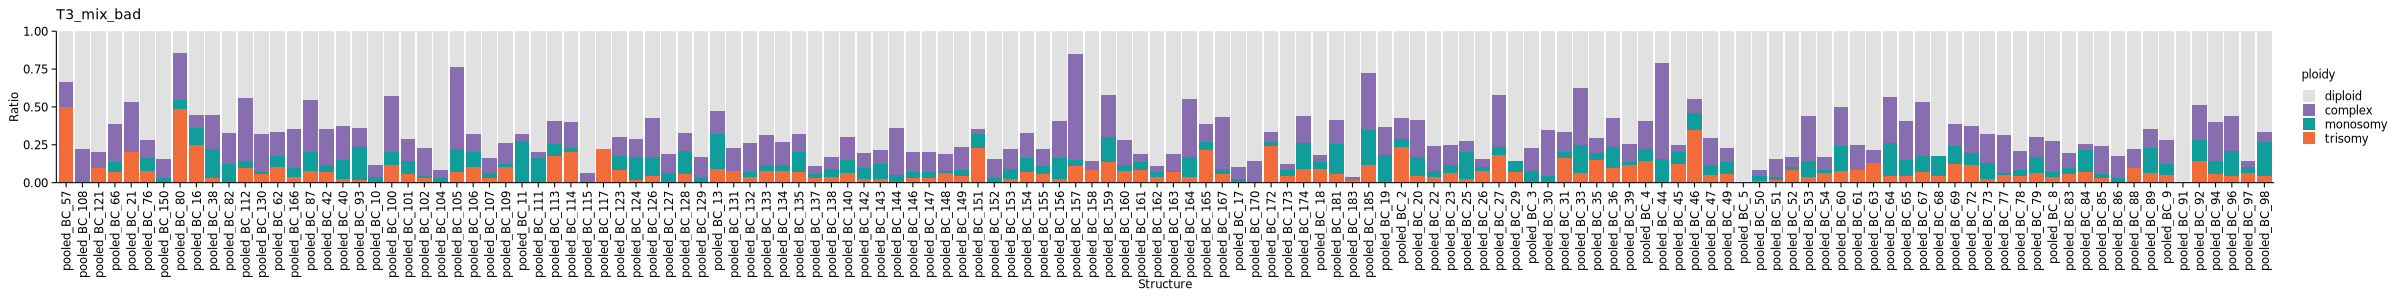

In [142]:
plot_ploidy_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_mix_bad",
  title        = "U4_ploidy_ratio_structure"
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


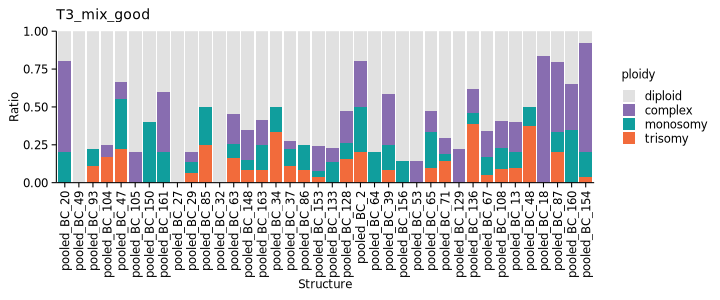

In [143]:
plot_ploidy_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_mix_good",
  title        = "U5_ploidy_ratio_structure",
   w = 6
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


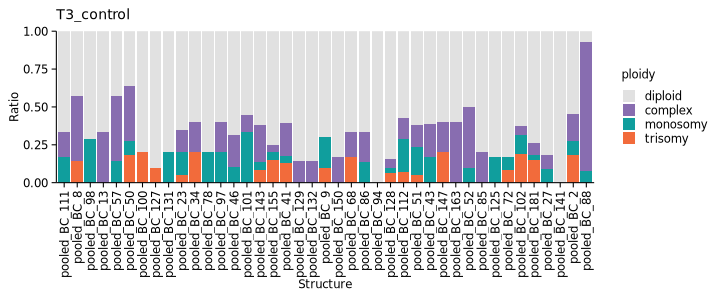

In [144]:
plot_ploidy_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_control",
  title        = "U6_ploidy_ratio_structure",
   w = 6
)

### O2) Plots of monosomies and trisomies

In [163]:
unique(cell_chr_karyo_df$ploidy_chr)

[1] "normal"   "trisomy"  "monosomy"

In [164]:
unique(cell_chr_karyo_df$ploidy_cell)

[1] "diploid"  "trisomy"  "monosomy" "complex"

In [ ]:
cell_chr_karyo_df <- cell_chr_karyo_df %>%
  rename(sample = sample_chr)

In [179]:
cell_chr_karyo_df <- cell_chr_karyo_df %>%
  rename(sample = sample_chr)

cell_chr_karyo_counts_int <- cell_chr_karyo_df %>%
  group_by(sample, ploidy_cell, chr, ploidy_chr) %>%
  summarise(count = n(), .groups = "drop")

cell_chr_karyo_counts = cell_chr_karyo_counts_int%>%
  group_by(sample, chr) %>%
  mutate(total_counts = sum(count)) %>%
  ungroup()

In [180]:
head(cell_chr_karyo_counts)

sample,ploidy_cell,chr,ploidy_chr,count,total_counts
<chr>,<chr>,<int>,<chr>,<int>,<int>
T1_control,complex,1,monosomy,37,4052
T1_control,complex,1,normal,372,4052
T1_control,complex,1,trisomy,33,4052
T1_control,complex,2,monosomy,69,4052
T1_control,complex,2,normal,345,4052
T1_control,complex,2,trisomy,28,4052


In [187]:
df_prop <- cell_chr_karyo_counts%>%
  mutate(
    prop = count / total_counts
  ) %>%
  ungroup()%>%
  select(chr, sample,ploidy_cell, ploidy_chr, prop)%>%
  pivot_wider(names_from = ploidy_cell, values_from = prop)

df_prop$chr <- as.factor(df_prop$chr)
 

head(df_prop)

chr,sample,ploidy_chr,complex,diploid,monosomy,trisomy
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,T1_control,monosomy,0.009131293,NA,0.003455084,NA
1,T1_control,normal,0.091806515,0.6767029,0.126110563,0.0839091807
1,T1_control,trisomy,0.008144126,NA,NA,0.0007403751
2,T1_control,monosomy,0.017028628,NA,0.013326752,NA
2,T1_control,normal,0.085143139,0.6767029,0.116238894,0.0802073050
2,T1_control,trisomy,0.006910168,NA,NA,0.0044422507


In [188]:
unique(df_prop$sample)

[1] "T1_control"   "T1_rev"       "T2_control"   "T2_mix"       "T2_rev"      
 [6] "T3_control"   "T3_mix_bad"   "T3_mix_good"  "T3_naive_rev" "T3_rev"

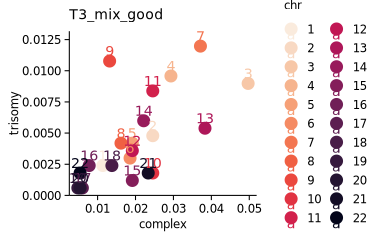

In [204]:
#plot
sample_name =  "T3_mix_good"
df_prop_sub = df_prop %>% subset(sample == sample_name)%>% subset(ploidy_chr == "trisomy")

title = "O2_scatter_T3_mix_good_tri"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = complex, y = trisomy, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  labs( title = sample_name) +
  settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

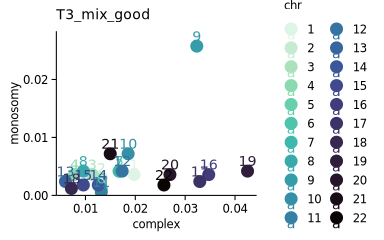

In [206]:
#plot
sample_name =  "T3_mix_good"
df_prop_sub = df_prop %>% subset(sample == sample_name)%>% subset(ploidy_chr == "monosomy")

title = "O2_scatter_T3_mix_good_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = complex, y = monosomy, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  labs(title = sample_name) +
  settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
   scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter